In [ ]:
# ============================================================
# EEG AD vs CN pipeline for your Google Drive setup
# Full script - paste into one Colab cell
# ============================================================

# ----------------------------
# 0) Mount Drive
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# 1) Imports
# ----------------------------
import os
import re
import math
import time
import pickle
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt, welch, coherence, resample_poly
from scipy.stats import entropy

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# ----------------------------
# 2) Config
# ----------------------------
RANDOM_STATE = 42

BASE_DIR = "/content/drive/MyDrive/eeg_hackathon"
TRAIN_DIR = f"{BASE_DIR}/Train"
TEST_DIR = f"{BASE_DIR}/Test"   # create later if you want held-out evaluation
LABEL_FILE = f"{TRAIN_DIR}/train_label_mapping.csv"

FEATURE_CACHE_DEV = f"{BASE_DIR}/dev_features_full.pkl"
RESULTS_CSV = f"{BASE_DIR}/dev_cv_results_full.csv"
THRESHOLDS_CSV = f"{BASE_DIR}/dev_threshold_results_full.csv"
BEST_MODEL_PKL = f"{BASE_DIR}/best_dev_model_full.pkl"
DEV_PREDS_CSV = f"{BASE_DIR}/dev_oof_predictions_full.csv"
TEST_PREDS_CSV = f"{BASE_DIR}/test_predictions_full.csv"

ORIG_FS = 500
TARGET_FS = 128

BANDPASS_LOW = 0.5
BANDPASS_HIGH = 45.0

WINDOW_SEC = 30
HOP_SEC = 15

USE_CACHE = True
RUN_LOSO = False           # set True later if you want a slower extra check
INCLUDE_COHERENCE = True   # set False if you want faster debug runs

CHANNEL_NAMES = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "T3", "C3", "Cz", "C4", "T4", "T5", "P3",
    "Pz", "P4", "T6", "O1", "O2"
]

BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 25.0),
    "gamma": (25.0, 45.0),
}

REGIONS = {
    "frontal":   ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
    "temporal":  ["T3", "T4", "T5", "T6"],
    "central":   ["C3", "Cz", "C4"],
    "parietal":  ["P3", "Pz", "P4"],
    "occipital": ["O1", "O2"],
}

REGION_PAIRS = list(combinations(REGIONS.keys(), 2))

DEV_IDS = sorted([
    3, 4, 8, 9, 18, 27, 28, 32, 34,
    40, 44, 46, 50, 51, 53, 55, 56, 61,
    70, 73, 76, 78, 81, 82, 86,
    10, 23, 24, 30, 39, 42, 48, 52, 64,
    69, 75, 84, 85, 87
])

MAX_ABS_UV_THRESHOLD = 500.0

# ----------------------------
# 3) Helpers
# ----------------------------
def set_seed(seed=RANDOM_STATE):
    np.random.seed(seed)

def ensure_2d_signal(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[0] != 19 and x.shape[1] == 19:
        x = x.T
    if x.shape[0] != 19:
        raise ValueError(f"Expected 19 channels, got shape {x.shape}")
    return x

def extract_numeric_id(text: str):
    nums = re.findall(r"\d+", str(text))
    return int(nums[-1]) if nums else None

CH_IDX = {ch: i for i, ch in enumerate(CHANNEL_NAMES)}
REGION_IDXS = {r: [CH_IDX[ch] for ch in chs] for r, chs in REGIONS.items()}

# ----------------------------
# 4) Labels + file maps
# ----------------------------
def load_labels(label_file: str) -> pd.DataFrame:
    df = pd.read_csv(label_file)
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

    # find id column
    id_col = None
    for c in ["participant_id", "subject_id", "anonymized_id", "id", "subject"]:
        if c in df.columns:
            id_col = c
            break
    if id_col is None:
        raise ValueError(f"Could not find subject id column. Columns: {df.columns.tolist()}")

    # find diagnosis/group column
    label_col = None
    for c in ["group", "diagnosis", "label", "condition"]:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        raise ValueError(f"Could not find diagnosis column. Columns: {df.columns.tolist()}")

    out = df[[id_col, label_col]].copy()
    out.columns = ["subject_id_raw", "label_raw"]
    out["subject_id"] = out["subject_id_raw"].apply(extract_numeric_id)

    def norm_label(x):
        x = str(x).strip().upper()
        if x in {"A", "AD", "ALZHEIMER", "ALZHEIMER'S", "ALZHEIMERS"}:
            return "AD"
        if x in {"C", "CN", "CONTROL", "HEALTHY"}:
            return "CN"
        if x in {"F", "FTD"}:
            return "FTD"
        return x

    out["group"] = out["label_raw"].apply(norm_label)
    out = out[out["group"].isin(["AD", "CN"])].copy()
    out["label"] = (out["group"] == "AD").astype(int)
    out = out.dropna(subset=["subject_id"]).copy()
    out["subject_id"] = out["subject_id"].astype(int)

    return out.sort_values("subject_id").reset_index(drop=True)

def build_file_map_from_group_folders(base_dir: str):
    file_map = {}
    for group in ["AD", "CN"]:
        folder = Path(base_dir) / group
        if not folder.exists():
            continue
        for fp in folder.glob("*.npy"):
            sid = extract_numeric_id(fp.stem)
            if sid is not None:
                file_map[int(sid)] = fp
    return file_map

# ----------------------------
# 5) Signal loading + preprocessing
# ----------------------------
def load_subject_eeg(npy_path: str) -> np.ndarray:
    x = np.load(npy_path, allow_pickle=True)
    return ensure_2d_signal(x)

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return b, a

def bandpass_filter(signal, fs, low=BANDPASS_LOW, high=BANDPASS_HIGH, order=4):
    b, a = butter_bandpass(low, high, fs, order)
    return filtfilt(b, a, signal, axis=-1)

def downsample_signal(signal, orig_fs=ORIG_FS, target_fs=TARGET_FS):
    if orig_fs == target_fs:
        return signal
    g = math.gcd(orig_fs, target_fs)
    up = target_fs // g
    down = orig_fs // g
    return resample_poly(signal, up=up, down=down, axis=-1)

def preprocess_signal(signal):
    signal = ensure_2d_signal(signal)
    signal = bandpass_filter(signal, fs=ORIG_FS)
    signal = downsample_signal(signal, orig_fs=ORIG_FS, target_fs=TARGET_FS)
    return signal.astype(np.float32)

# ----------------------------
# 6) Windowing
# ----------------------------
def make_windows(signal, fs=TARGET_FS, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    win = int(window_sec * fs)
    hop = int(hop_sec * fs)
    T = signal.shape[1]

    if T < win:
        return np.empty((0, signal.shape[0], win), dtype=np.float32)

    windows = []
    for start in range(0, T - win + 1, hop):
        windows.append(signal[:, start:start + win])
    return np.stack(windows, axis=0).astype(np.float32)

def is_clean_window(window, max_abs_threshold=MAX_ABS_UV_THRESHOLD):
    if not np.isfinite(window).all():
        return False
    if np.max(np.abs(window)) > max_abs_threshold:
        return False
    if np.any(np.std(window, axis=1) < 1e-6):
        return False
    return True

def get_clean_windows(signal):
    windows = make_windows(signal)
    if len(windows) == 0:
        return windows
    keep = np.array([is_clean_window(w) for w in windows], dtype=bool)
    return windows[keep]

# ----------------------------
# 7) Feature extraction
# ----------------------------
def band_mask(freqs, lo, hi):
    return (freqs >= lo) & (freqs < hi)

def compute_psd(window, fs=TARGET_FS):
    freqs, psd = welch(
        window,
        fs=fs,
        nperseg=min(fs * 4, window.shape[-1]),
        noverlap=min(fs * 2, max(0, window.shape[-1] // 2)),
        axis=-1
    )
    return freqs, psd

def relative_band_power(psd, freqs):
    total_mask = band_mask(freqs, BANDPASS_LOW, BANDPASS_HIGH)
    total_power = psd[:, total_mask].sum(axis=1) + 1e-10
    out = {}
    for band_name, (lo, hi) in BANDS.items():
        mask = band_mask(freqs, lo, hi)
        out[band_name] = psd[:, mask].sum(axis=1) / total_power
    return out

def spectral_entropy_from_psd(psd_1d):
    psd_norm = psd_1d / (psd_1d.sum() + 1e-10)
    return float(entropy(psd_norm + 1e-12, base=2) / np.log2(len(psd_norm) + 1e-12))

def hjorth_parameters(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var_x = np.var(x) + 1e-10
    var_dx = np.var(dx) + 1e-10
    var_ddx = np.var(ddx) + 1e-10

    activity = var_x
    mobility = np.sqrt(var_dx / var_x)
    complexity = np.sqrt(var_ddx / var_dx) / (mobility + 1e-10)
    return float(activity), float(mobility), float(complexity)

def compute_regional_means(channel_values):
    return {region: float(np.mean(channel_values[idxs])) for region, idxs in REGION_IDXS.items()}

def compute_region_coherence(window, fs=TARGET_FS):
    out = {}
    for r1, r2 in REGION_PAIRS:
        idxs1 = REGION_IDXS[r1]
        idxs2 = REGION_IDXS[r2]

        for band_name, (lo, hi) in BANDS.items():
            vals = []
            for i in idxs1:
                for j in idxs2:
                    f, coh = coherence(
                        window[i], window[j],
                        fs=fs,
                        nperseg=min(fs * 4, window.shape[-1]),
                        noverlap=min(fs * 2, max(0, window.shape[-1] // 2))
                    )
                    mask = band_mask(f, lo, hi)
                    if np.any(mask):
                        vals.append(float(np.mean(coh[mask])))
            out[f"coh_{r1}_{r2}_{band_name}"] = float(np.mean(vals)) if len(vals) else np.nan
    return out

def extract_window_features(window):
    feats = {}

    freqs, psd = compute_psd(window)
    rbp = relative_band_power(psd, freqs)

    global_band = {}
    for band_name, vals in rbp.items():
        reg = compute_regional_means(vals)
        for region, value in reg.items():
            feats[f"rbp_{band_name}_{region}"] = value
        global_band[band_name] = float(np.mean(vals))
        feats[f"rbp_{band_name}_global"] = global_band[band_name]

    def safe_ratio(a, b):
        return float(a / (b + 1e-10))

    feats["ratio_theta_alpha_global"] = safe_ratio(global_band["theta"], global_band["alpha"])
    feats["ratio_delta_alpha_global"] = safe_ratio(global_band["delta"], global_band["alpha"])
    feats["ratio_alpha_beta_global"] = safe_ratio(global_band["alpha"], global_band["beta"])
    feats["slowing_index_global"] = safe_ratio(global_band["delta"] + global_band["theta"], global_band["alpha"] + global_band["beta"])

    for region in REGIONS:
        d = feats[f"rbp_delta_{region}"]
        t = feats[f"rbp_theta_{region}"]
        a = feats[f"rbp_alpha_{region}"]
        b = feats[f"rbp_beta_{region}"]
        feats[f"ratio_theta_alpha_{region}"] = safe_ratio(t, a)
        feats[f"ratio_delta_alpha_{region}"] = safe_ratio(d, a)
        feats[f"slowing_index_{region}"] = safe_ratio(d + t, a + b)

    hj_a, hj_m, hj_c = [], [], []
    for ch in range(window.shape[0]):
        a, m, c = hjorth_parameters(window[ch])
        hj_a.append(a); hj_m.append(m); hj_c.append(c)

    hj_a = np.array(hj_a)
    hj_m = np.array(hj_m)
    hj_c = np.array(hj_c)

    for region, idxs in REGION_IDXS.items():
        feats[f"hjorth_activity_{region}"] = float(np.mean(hj_a[idxs]))
        feats[f"hjorth_mobility_{region}"] = float(np.mean(hj_m[idxs]))
        feats[f"hjorth_complexity_{region}"] = float(np.mean(hj_c[idxs]))

    total_mask = band_mask(freqs, BANDPASS_LOW, BANDPASS_HIGH)
    se = np.array([spectral_entropy_from_psd(psd[ch, total_mask]) for ch in range(psd.shape[0])])
    for region, idxs in REGION_IDXS.items():
        feats[f"specent_{region}"] = float(np.mean(se[idxs]))
    feats["specent_global"] = float(np.mean(se))

    if INCLUDE_COHERENCE:
        feats.update(compute_region_coherence(window))

    return feats

# ----------------------------
# 8) Subject-level aggregation
# ----------------------------
def aggregate_window_features(window_df: pd.DataFrame) -> pd.Series:
    mean_feats = window_df.mean(axis=0).add_suffix("__mean")
    std_feats = window_df.std(axis=0, ddof=0).fillna(0.0).add_suffix("__std")
    return pd.concat([mean_feats, std_feats])

def build_subject_feature_vector(signal):
    windows = get_clean_windows(signal)
    if len(windows) == 0:
        return None, 0

    rows = [extract_window_features(w) for w in windows]
    window_df = pd.DataFrame(rows)
    subject_series = aggregate_window_features(window_df)
    return subject_series, len(windows)

# ----------------------------
# 9) Build or load dev features
# ----------------------------
def build_dev_feature_table(train_dir, label_file, cache_path=None, use_cache=False):
    if use_cache and cache_path and os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            payload = pickle.load(f)
        print(f"Loaded cached dev features from {cache_path}")
        return payload["X"], payload["y"], payload["meta"], payload["feature_names"]

    labels = load_labels(label_file)
    labels = labels[labels["subject_id"].isin(DEV_IDS)].copy()

    file_map = build_file_map_from_group_folders(train_dir)

    rows = []
    meta_rows = []

    start_total = time.time()

    for idx, row in labels.iterrows():
        sid = int(row["subject_id"])
        label = int(row["label"])

        if sid not in file_map:
            print(f"[WARN] Missing dev EEG file for subject {sid}; skipping.")
            continue

        t0 = time.time()
        eeg = load_subject_eeg(file_map[sid])
        eeg = preprocess_signal(eeg)

        subject_feats, n_windows = build_subject_feature_vector(eeg)
        if subject_feats is None:
            print(f"[WARN] No clean windows for subject {sid}; skipping.")
            continue

        rows.append(subject_feats)
        meta_rows.append({
            "subject_id": sid,
            "label": label,
            "n_windows": n_windows,
            "file_path": str(file_map[sid]),
        })

        print(f"[OK] DEV subject {sid} | label={label} | windows={n_windows} | {(time.time()-t0):.1f}s")

    X_df = pd.DataFrame(rows).reset_index(drop=True)
    meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)

    feature_names = X_df.columns.tolist()
    X = X_df.values.astype(np.float32)
    y = meta_df["label"].values.astype(int)

    payload = {"X": X, "y": y, "meta": meta_df, "feature_names": feature_names}
    if cache_path:
        with open(cache_path, "wb") as f:
            pickle.dump(payload, f)
        print(f"Saved dev features to {cache_path}")

    print(f"Total feature build time: {(time.time() - start_total)/60:.2f} min")
    return X, y, meta_df, feature_names

# ----------------------------
# 10) Models
# ----------------------------
def make_model_dict():
    models = {}

    # Baseline from your first run
    models["logreg_enet_k60_C0.5_l10.3"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=60)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.3,
            C=0.5,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    # Stronger regularized + class-balanced variants
    models["logreg_enet_k40_C0.2_l10.5_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=40)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["logreg_enet_k50_C0.2_l10.5_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["logreg_enet_k60_C0.2_l10.5_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=60)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    # Standard balanced logistic
    models["logreg_l2_k40_C0.2_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=40)),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["logreg_l2_k50_C0.2_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    # SVM variants
    models["svm_rbf_k40_C1_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=40)),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    models["svm_rbf_k50_C1_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    # Tree baseline
    models["hgb_k40_depth3"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("select", SelectKBest(f_classif, k=40)),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=3,
            max_iter=200,
            min_samples_leaf=4,
            random_state=RANDOM_STATE
        ))
    ])

    models["hgb_k50_depth3"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("select", SelectKBest(f_classif, k=50)),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=3,
            max_iter=200,
            min_samples_leaf=4,
            random_state=RANDOM_STATE
        ))
    ])

    # Soft vote of stronger models
    models["soft_vote_strong"] = VotingClassifier(
        estimators=[
            ("lr1", clone(models["logreg_enet_k50_C0.2_l10.5_bal"])),
            ("lr2", clone(models["logreg_l2_k50_C0.2_bal"])),
            ("svm", clone(models["svm_rbf_k50_C1_bal"])),
        ],
        voting="soft",
        weights=[2, 2, 1]
    )

    return models

# ----------------------------
# 11) Metrics + threshold tuning
# ----------------------------
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    f1_bin = f1_score(y_true, y_pred, average="binary")
    f1_macro = f1_score(y_true, y_pred, average="macro")

    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn + 1e-10)
    specificity = tn / (tn + fp + 1e-10)

    return {
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1": f1_bin,
        "f1_macro": f1_macro,
        "roc_auc": auc,
        "sensitivity": sensitivity,
        "specificity": specificity
    }

def print_metrics(title, metrics):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    for k, v in metrics.items():
        print(f"{k:>18}: {v:.4f}")

def evaluate_cv(model, X, y, cv, model_name="model"):
    oof_prob = np.zeros(len(y), dtype=float)

    for fold, (tr, va) in enumerate(cv.split(X, y), 1):
        m = clone(model)
        m.fit(X[tr], y[tr])
        p = m.predict_proba(X[va])[:, 1]
        oof_prob[va] = p
        print(f"[{model_name}] fold {fold} done | n_train={len(tr)} | n_val={len(va)}")

    metrics = compute_metrics(y, oof_prob, threshold=0.5)
    return metrics, oof_prob

def tune_threshold(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.20, 0.80, 61)

    rows = []
    for t in grid:
        m = compute_metrics(y_true, y_prob, threshold=t)
        rows.append({"threshold": float(t), **m})

    df = pd.DataFrame(rows).sort_values(
        ["balanced_accuracy", "f1_macro", "f1", "roc_auc"],
        ascending=False
    ).reset_index(drop=True)

    return df, float(df.iloc[0]["threshold"])

# ----------------------------
# 12) Build/load dev features
# ----------------------------
set_seed()

print("\nChecking Drive structure...")
print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("LABEL_FILE exists:", os.path.exists(LABEL_FILE))
if os.path.exists(TRAIN_DIR):
    print("TRAIN contents:", os.listdir(TRAIN_DIR))

start = time.time()
X_dev, y_dev, meta_dev, feature_names = build_dev_feature_table(
    train_dir=TRAIN_DIR,
    label_file=LABEL_FILE,
    cache_path=FEATURE_CACHE_DEV,
    use_cache=USE_CACHE
)
print(f"\nLoaded/build dev features in {(time.time()-start)/60:.2f} min")
print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)
print("Subjects loaded:", meta_dev["subject_id"].tolist())
print("Class counts:", dict(zip(*np.unique(y_dev, return_counts=True))))

# ----------------------------
# 13) Dev CV across stronger model set
# ----------------------------
models = make_model_dict()
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_results = []
all_thresh = []
oof_store = {}

start_cv = time.time()

for name, model in models.items():
    print(f"\nRunning CV for {name} ...")
    metrics_05, oof_prob = evaluate_cv(model, X_dev, y_dev, cv5, model_name=name)

    thresh_df, best_thresh = tune_threshold(y_dev, oof_prob)
    tuned_metrics = compute_metrics(y_dev, oof_prob, threshold=best_thresh)

    print_metrics(f"DEV 5-FOLD CV | {name} | threshold=0.50", metrics_05)
    print_metrics(f"DEV 5-FOLD CV | {name} | tuned threshold={best_thresh:.2f}", tuned_metrics)

    row = {
        "model": name,
        "threshold_default": 0.50,
        "threshold_tuned": best_thresh,

        "acc_05": metrics_05["accuracy"],
        "bacc_05": metrics_05["balanced_accuracy"],
        "f1_05": metrics_05["f1"],
        "f1_macro_05": metrics_05["f1_macro"],
        "auc_05": metrics_05["roc_auc"],
        "sens_05": metrics_05["sensitivity"],
        "spec_05": metrics_05["specificity"],

        "acc_tuned": tuned_metrics["accuracy"],
        "bacc_tuned": tuned_metrics["balanced_accuracy"],
        "f1_tuned": tuned_metrics["f1"],
        "f1_macro_tuned": tuned_metrics["f1_macro"],
        "auc_tuned": tuned_metrics["roc_auc"],
        "sens_tuned": tuned_metrics["sensitivity"],
        "spec_tuned": tuned_metrics["specificity"],
    }
    all_results.append(row)

    thresh_tmp = thresh_df.copy()
    thresh_tmp["model"] = name
    all_thresh.append(thresh_tmp)

    oof_store[name] = oof_prob

print(f"\nTotal CV time: {(time.time()-start_cv)/60:.2f} min")

results_df = pd.DataFrame(all_results).sort_values(
    ["bacc_tuned", "f1_macro_tuned", "f1_tuned", "auc_tuned"],
    ascending=False
).reset_index(drop=True)

thresholds_df = pd.concat(all_thresh, axis=0).reset_index(drop=True)

print("\n================ FINAL DEV MODEL RANKING ================\n")
print(results_df[[
    "model",
    "threshold_tuned",
    "bacc_05", "bacc_tuned",
    "f1_05", "f1_tuned",
    "f1_macro_05", "f1_macro_tuned",
    "auc_05", "auc_tuned",
    "sens_05", "sens_tuned",
    "spec_05", "spec_tuned"
]].to_string(index=False))

results_df.to_csv(RESULTS_CSV, index=False)
thresholds_df.to_csv(THRESHOLDS_CSV, index=False)
print(f"\nSaved dev results to {RESULTS_CSV}")
print(f"Saved threshold table to {THRESHOLDS_CSV}")

# Save OOF predictions for inspection
oof_df = meta_dev.copy()
for name, probs in oof_store.items():
    oof_df[f"prob_{name}"] = probs
oof_df.to_csv(DEV_PREDS_CSV, index=False)
print(f"Saved OOF predictions to {DEV_PREDS_CSV}")

# ----------------------------
# 14) Optional LOSO on best few
# ----------------------------
if RUN_LOSO:
    top_names = results_df["model"].head(3).tolist()
    loo = LeaveOneOut()
    print("\nRunning LOSO on top models:", top_names)

    loso_rows = []
    for name in top_names:
        model = models[name]
        metrics_05, oof_prob = evaluate_cv(model, X_dev, y_dev, loo, model_name=f"{name}_LOSO")
        thresh_df, best_thresh = tune_threshold(y_dev, oof_prob)
        tuned_metrics = compute_metrics(y_dev, oof_prob, threshold=best_thresh)

        loso_rows.append({
            "model": name,
            "threshold_tuned": best_thresh,
            "bacc_05": metrics_05["balanced_accuracy"],
            "bacc_tuned": tuned_metrics["balanced_accuracy"],
            "f1_05": metrics_05["f1"],
            "f1_tuned": tuned_metrics["f1"],
            "f1_macro_05": metrics_05["f1_macro"],
            "f1_macro_tuned": tuned_metrics["f1_macro"],
            "auc_05": metrics_05["roc_auc"],
            "auc_tuned": tuned_metrics["roc_auc"],
        })

    loso_df = pd.DataFrame(loso_rows).sort_values(
        ["bacc_tuned", "f1_macro_tuned", "auc_tuned"],
        ascending=False
    )
    print("\n================ LOSO CHECK ================\n")
    print(loso_df.to_string(index=False))

# ----------------------------
# 15) Fit best model on all dev subjects
# ----------------------------
best_row = results_df.iloc[0]
best_model_name = best_row["model"]
best_threshold = float(best_row["threshold_tuned"])
best_model = clone(models[best_model_name])

print(f"\nBest model selected: {best_model_name}")
print(f"Best tuned threshold: {best_threshold:.2f}")

best_model.fit(X_dev, y_dev)

with open(BEST_MODEL_PKL, "wb") as f:
    pickle.dump({
        "model_name": best_model_name,
        "threshold": best_threshold,
        "model": best_model,
        "feature_names": feature_names,
        "results": results_df,
        "meta_dev": meta_dev,
        "include_coherence": INCLUDE_COHERENCE,
    }, f)

print(f"Saved best model to {BEST_MODEL_PKL}")

# ----------------------------
# 16) Optional held-out test evaluation later
# ----------------------------
def build_test_feature_table(test_dir, label_file, feature_names):
    labels = load_labels(label_file)
    labels = labels[~labels["subject_id"].isin(DEV_IDS)].copy()

    file_map = build_file_map_from_group_folders(test_dir)

    rows = []
    meta_rows = []

    for _, row in labels.iterrows():
        sid = int(row["subject_id"])
        label = int(row["label"])

        if sid not in file_map:
            print(f"[WARN] Missing test EEG file for subject {sid}; skipping.")
            continue

        eeg = load_subject_eeg(file_map[sid])
        eeg = preprocess_signal(eeg)

        subject_feats, n_windows = build_subject_feature_vector(eeg)
        if subject_feats is None:
            print(f"[WARN] No clean windows for subject {sid}; skipping.")
            continue

        rows.append(subject_feats)
        meta_rows.append({
            "subject_id": sid,
            "label": label,
            "n_windows": n_windows,
            "file_path": str(file_map[sid]),
        })

        print(f"[OK] TEST subject {sid} | label={label} | windows={n_windows}")

    X_df = pd.DataFrame(rows).reset_index(drop=True)
    meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)

    for c in feature_names:
        if c not in X_df.columns:
            X_df[c] = np.nan
    X_df = X_df[feature_names]

    X_test = X_df.values.astype(np.float32)
    y_test = meta_df["label"].values.astype(int)

    return X_test, y_test, meta_df

if os.path.exists(TEST_DIR):
    print("\nFound TEST_DIR. Running held-out test evaluation...")
    print("TEST_DIR contents:", os.listdir(TEST_DIR))

    X_test, y_test, meta_test = build_test_feature_table(
        test_dir=TEST_DIR,
        label_file=LABEL_FILE,
        feature_names=feature_names
    )

    print("X_test shape:", X_test.shape)
    print("Held-out test subjects:", meta_test["subject_id"].tolist())
    print("Test class counts:", dict(zip(*np.unique(y_test, return_counts=True))))

    test_prob = best_model.predict_proba(X_test)[:, 1]
    test_metrics = compute_metrics(y_test, test_prob, threshold=best_threshold)

    print_metrics("FINAL HELD-OUT TEST RESULTS", test_metrics)

    test_preds_df = meta_test.copy()
    test_preds_df["prob_ad"] = test_prob
    test_preds_df["pred"] = (test_prob >= best_threshold).astype(int)
    test_preds_df["pred_label"] = np.where(test_preds_df["pred"] == 1, "A", "C")
    test_preds_df.to_csv(TEST_PREDS_CSV, index=False)
    print(f"Saved test predictions to {TEST_PREDS_CSV}")
else:
    print("\nNo TEST_DIR found yet. That is fine.")
    print(f"When ready, create: {TEST_DIR}")
    print("with subfolders AD/ and CN/, then rerun only the final test section.")

Mounted at /content/drive

Checking Drive structure...
BASE_DIR exists: True
TRAIN_DIR exists: True
LABEL_FILE exists: True
TRAIN contents: ['AD', 'CN', 'train_label_mapping.csv']
[OK] DEV subject 3 | label=1 | windows=14 | 42.1s
[OK] DEV subject 4 | label=1 | windows=9 | 26.7s
[OK] DEV subject 8 | label=1 | windows=12 | 34.7s
[OK] DEV subject 9 | label=1 | windows=13 | 38.7s
[OK] DEV subject 10 | label=0 | windows=14 | 40.8s
[OK] DEV subject 18 | label=1 | windows=13 | 37.9s
[OK] DEV subject 23 | label=0 | windows=11 | 31.5s
[OK] DEV subject 24 | label=0 | windows=13 | 38.4s
[OK] DEV subject 27 | label=1 | windows=12 | 34.6s
[OK] DEV subject 28 | label=1 | windows=13 | 37.9s
[OK] DEV subject 30 | label=0 | windows=13 | 38.4s
[OK] DEV subject 32 | label=1 | windows=11 | 31.7s
[OK] DEV subject 34 | label=1 | windows=11 | 31.4s
[OK] DEV subject 39 | label=0 | windows=14 | 41.7s
[OK] DEV subject 40 | label=1 | windows=20 | 58.0s
[OK] DEV subject 42 | label=0 | windows=13 | 38.2s
[OK] DEV 

In [2]:
# ============================================================
# EEG AD vs CN pipeline for your Google Drive setup
# FINAL VERSION
# - Keeps the strongest working dev pipeline
# - Uses unlabeled /testing folder for final inference
# - Saves CV results, best model, OOF predictions, and test predictions
# ============================================================

# ----------------------------
# 0) Mount Drive
# ----------------------------
from google.colab import drive
drive.mount('/content/drive')

# ----------------------------
# 1) Imports
# ----------------------------
import os
import re
import math
import time
import pickle
import warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd

from scipy.signal import butter, filtfilt, welch, coherence, resample_poly
from scipy.stats import entropy

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, VotingClassifier
from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# ----------------------------
# 2) Config
# ----------------------------
RANDOM_STATE = 42

BASE_DIR = "/content/drive/MyDrive/eeg_hackathon"
TRAIN_DIR = f"{BASE_DIR}/Train"
TEST_DIR = f"{BASE_DIR}/testing"   # unlabeled testing folder
LABEL_FILE = f"{TRAIN_DIR}/train_label_mapping.csv"

FEATURE_CACHE_DEV = f"{BASE_DIR}/dev_features_full.pkl"
RESULTS_CSV = f"{BASE_DIR}/dev_cv_results_full.csv"
THRESHOLDS_CSV = f"{BASE_DIR}/dev_threshold_results_full.csv"
BEST_MODEL_PKL = f"{BASE_DIR}/best_dev_model_full.pkl"
DEV_PREDS_CSV = f"{BASE_DIR}/dev_oof_predictions_full.csv"
TEST_PREDS_CSV = f"{BASE_DIR}/test_predictions_final.csv"

ORIG_FS = 500
TARGET_FS = 128

BANDPASS_LOW = 0.5
BANDPASS_HIGH = 45.0

WINDOW_SEC = 30
HOP_SEC = 15

USE_CACHE = True
RUN_LOSO = False           # set True if you want slower extra check
INCLUDE_COHERENCE = True

CHANNEL_NAMES = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8",
    "T3", "C3", "Cz", "C4", "T4", "T5", "P3",
    "Pz", "P4", "T6", "O1", "O2"
]

BANDS = {
    "delta": (0.5, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 25.0),
    "gamma": (25.0, 45.0),
}

REGIONS = {
    "frontal":   ["Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8"],
    "temporal":  ["T3", "T4", "T5", "T6"],
    "central":   ["C3", "Cz", "C4"],
    "parietal":  ["P3", "Pz", "P4"],
    "occipital": ["O1", "O2"],
}

REGION_PAIRS = list(combinations(REGIONS.keys(), 2))

DEV_IDS = sorted([
    3, 4, 8, 9, 18, 27, 28, 32, 34,
    40, 44, 46, 50, 51, 53, 55, 56, 61,
    70, 73, 76, 78, 81, 82, 86,
    10, 23, 24, 30, 39, 42, 48, 52, 64,
    69, 75, 84, 85, 87
])

MAX_ABS_UV_THRESHOLD = 500.0

# ----------------------------
# 3) Helpers
# ----------------------------
def set_seed(seed=RANDOM_STATE):
    np.random.seed(seed)

def ensure_2d_signal(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")
    if x.shape[0] != 19 and x.shape[1] == 19:
        x = x.T
    if x.shape[0] != 19:
        raise ValueError(f"Expected 19 channels, got shape {x.shape}")
    return x

def extract_numeric_id(text: str):
    nums = re.findall(r"\d+", str(text))
    return int(nums[-1]) if nums else None

CH_IDX = {ch: i for i, ch in enumerate(CHANNEL_NAMES)}
REGION_IDXS = {r: [CH_IDX[ch] for ch in chs] for r, chs in REGIONS.items()}

# ----------------------------
# 4) Labels + file maps
# ----------------------------
def load_labels(label_file: str) -> pd.DataFrame:
    df = pd.read_csv(label_file)
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

    id_col = None
    for c in ["participant_id", "subject_id", "anonymized_id", "id", "subject"]:
        if c in df.columns:
            id_col = c
            break
    if id_col is None:
        raise ValueError(f"Could not find subject id column. Columns: {df.columns.tolist()}")

    label_col = None
    for c in ["group", "diagnosis", "label", "condition"]:
        if c in df.columns:
            label_col = c
            break
    if label_col is None:
        raise ValueError(f"Could not find diagnosis column. Columns: {df.columns.tolist()}")

    out = df[[id_col, label_col]].copy()
    out.columns = ["subject_id_raw", "label_raw"]
    out["subject_id"] = out["subject_id_raw"].apply(extract_numeric_id)

    def norm_label(x):
        x = str(x).strip().upper()
        if x in {"A", "AD", "ALZHEIMER", "ALZHEIMER'S", "ALZHEIMERS"}:
            return "AD"
        if x in {"C", "CN", "CONTROL", "HEALTHY"}:
            return "CN"
        if x in {"F", "FTD"}:
            return "FTD"
        return x

    out["group"] = out["label_raw"].apply(norm_label)
    out = out[out["group"].isin(["AD", "CN"])].copy()
    out["label"] = (out["group"] == "AD").astype(int)
    out = out.dropna(subset=["subject_id"]).copy()
    out["subject_id"] = out["subject_id"].astype(int)

    return out.sort_values("subject_id").reset_index(drop=True)

def build_file_map_from_group_folders(base_dir: str):
    file_map = {}
    for group in ["AD", "CN"]:
        folder = Path(base_dir) / group
        if not folder.exists():
            continue
        for fp in folder.glob("*.npy"):
            sid = extract_numeric_id(fp.stem)
            if sid is not None:
                file_map[int(sid)] = fp
    return file_map

def build_recursive_npy_file_map(base_dir: str):
    file_map = {}
    for fp in sorted(Path(base_dir).rglob("*.npy"), key=lambda p: extract_numeric_id(p.stem) or -1):
        sid = extract_numeric_id(fp.stem)
        if sid is not None:
            file_map[int(sid)] = fp
    return file_map

# ----------------------------
# 5) Signal loading + preprocessing
# ----------------------------
def load_subject_eeg(npy_path: str) -> np.ndarray:
    x = np.load(npy_path, allow_pickle=True)
    return ensure_2d_signal(x)

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype="band")
    return b, a

def bandpass_filter(signal, fs, low=BANDPASS_LOW, high=BANDPASS_HIGH, order=4):
    b, a = butter_bandpass(low, high, fs, order)
    return filtfilt(b, a, signal, axis=-1)

def downsample_signal(signal, orig_fs=ORIG_FS, target_fs=TARGET_FS):
    if orig_fs == target_fs:
        return signal
    g = math.gcd(orig_fs, target_fs)
    up = target_fs // g
    down = orig_fs // g
    return resample_poly(signal, up=up, down=down, axis=-1)

def preprocess_signal(signal):
    signal = ensure_2d_signal(signal)
    signal = bandpass_filter(signal, fs=ORIG_FS)
    signal = downsample_signal(signal, orig_fs=ORIG_FS, target_fs=TARGET_FS)
    return signal.astype(np.float32)

# ----------------------------
# 6) Windowing
# ----------------------------
def make_windows(signal, fs=TARGET_FS, window_sec=WINDOW_SEC, hop_sec=HOP_SEC):
    win = int(window_sec * fs)
    hop = int(hop_sec * fs)
    T = signal.shape[1]

    if T < win:
        return np.empty((0, signal.shape[0], win), dtype=np.float32)

    windows = []
    for start in range(0, T - win + 1, hop):
        windows.append(signal[:, start:start + win])
    return np.stack(windows, axis=0).astype(np.float32)

def is_clean_window(window, max_abs_threshold=MAX_ABS_UV_THRESHOLD):
    if not np.isfinite(window).all():
        return False
    if np.max(np.abs(window)) > max_abs_threshold:
        return False
    if np.any(np.std(window, axis=1) < 1e-6):
        return False
    return True

def get_clean_windows(signal):
    windows = make_windows(signal)
    if len(windows) == 0:
        return windows
    keep = np.array([is_clean_window(w) for w in windows], dtype=bool)
    return windows[keep]

# ----------------------------
# 7) Feature extraction
# ----------------------------
def band_mask(freqs, lo, hi):
    return (freqs >= lo) & (freqs < hi)

def compute_psd(window, fs=TARGET_FS):
    freqs, psd = welch(
        window,
        fs=fs,
        nperseg=min(fs * 4, window.shape[-1]),
        noverlap=min(fs * 2, max(0, window.shape[-1] // 2)),
        axis=-1
    )
    return freqs, psd

def relative_band_power(psd, freqs):
    total_mask = band_mask(freqs, BANDPASS_LOW, BANDPASS_HIGH)
    total_power = psd[:, total_mask].sum(axis=1) + 1e-10
    out = {}
    for band_name, (lo, hi) in BANDS.items():
        mask = band_mask(freqs, lo, hi)
        out[band_name] = psd[:, mask].sum(axis=1) / total_power
    return out

def spectral_entropy_from_psd(psd_1d):
    psd_norm = psd_1d / (psd_1d.sum() + 1e-10)
    return float(entropy(psd_norm + 1e-12, base=2) / np.log2(len(psd_norm) + 1e-12))

def hjorth_parameters(x):
    dx = np.diff(x)
    ddx = np.diff(dx)

    var_x = np.var(x) + 1e-10
    var_dx = np.var(dx) + 1e-10
    var_ddx = np.var(ddx) + 1e-10

    activity = var_x
    mobility = np.sqrt(var_dx / var_x)
    complexity = np.sqrt(var_ddx / var_dx) / (mobility + 1e-10)
    return float(activity), float(mobility), float(complexity)

def compute_regional_means(channel_values):
    return {region: float(np.mean(channel_values[idxs])) for region, idxs in REGION_IDXS.items()}

def compute_region_coherence(window, fs=TARGET_FS):
    out = {}
    for r1, r2 in REGION_PAIRS:
        idxs1 = REGION_IDXS[r1]
        idxs2 = REGION_IDXS[r2]

        for band_name, (lo, hi) in BANDS.items():
            vals = []
            for i in idxs1:
                for j in idxs2:
                    f, coh = coherence(
                        window[i], window[j],
                        fs=fs,
                        nperseg=min(fs * 4, window.shape[-1]),
                        noverlap=min(fs * 2, max(0, window.shape[-1] // 2))
                    )
                    mask = band_mask(f, lo, hi)
                    if np.any(mask):
                        vals.append(float(np.mean(coh[mask])))
            out[f"coh_{r1}_{r2}_{band_name}"] = float(np.mean(vals)) if len(vals) else np.nan
    return out

def extract_window_features(window):
    feats = {}

    freqs, psd = compute_psd(window)
    rbp = relative_band_power(psd, freqs)

    global_band = {}
    for band_name, vals in rbp.items():
        reg = compute_regional_means(vals)
        for region, value in reg.items():
            feats[f"rbp_{band_name}_{region}"] = value
        global_band[band_name] = float(np.mean(vals))
        feats[f"rbp_{band_name}_global"] = global_band[band_name]

    def safe_ratio(a, b):
        return float(a / (b + 1e-10))

    feats["ratio_theta_alpha_global"] = safe_ratio(global_band["theta"], global_band["alpha"])
    feats["ratio_delta_alpha_global"] = safe_ratio(global_band["delta"], global_band["alpha"])
    feats["ratio_alpha_beta_global"] = safe_ratio(global_band["alpha"], global_band["beta"])
    feats["slowing_index_global"] = safe_ratio(global_band["delta"] + global_band["theta"], global_band["alpha"] + global_band["beta"])

    for region in REGIONS:
        d = feats[f"rbp_delta_{region}"]
        t = feats[f"rbp_theta_{region}"]
        a = feats[f"rbp_alpha_{region}"]
        b = feats[f"rbp_beta_{region}"]
        feats[f"ratio_theta_alpha_{region}"] = safe_ratio(t, a)
        feats[f"ratio_delta_alpha_{region}"] = safe_ratio(d, a)
        feats[f"slowing_index_{region}"] = safe_ratio(d + t, a + b)

    hj_a, hj_m, hj_c = [], [], []
    for ch in range(window.shape[0]):
        a, m, c = hjorth_parameters(window[ch])
        hj_a.append(a); hj_m.append(m); hj_c.append(c)

    hj_a = np.array(hj_a)
    hj_m = np.array(hj_m)
    hj_c = np.array(hj_c)

    for region, idxs in REGION_IDXS.items():
        feats[f"hjorth_activity_{region}"] = float(np.mean(hj_a[idxs]))
        feats[f"hjorth_mobility_{region}"] = float(np.mean(hj_m[idxs]))
        feats[f"hjorth_complexity_{region}"] = float(np.mean(hj_c[idxs]))

    total_mask = band_mask(freqs, BANDPASS_LOW, BANDPASS_HIGH)
    se = np.array([spectral_entropy_from_psd(psd[ch, total_mask]) for ch in range(psd.shape[0])])
    for region, idxs in REGION_IDXS.items():
        feats[f"specent_{region}"] = float(np.mean(se[idxs]))
    feats["specent_global"] = float(np.mean(se))

    if INCLUDE_COHERENCE:
        feats.update(compute_region_coherence(window))

    return feats

# ----------------------------
# 8) Subject-level aggregation
# ----------------------------
def aggregate_window_features(window_df: pd.DataFrame) -> pd.Series:
    mean_feats = window_df.mean(axis=0).add_suffix("__mean")
    std_feats = window_df.std(axis=0, ddof=0).fillna(0.0).add_suffix("__std")
    return pd.concat([mean_feats, std_feats])

def build_subject_feature_vector(signal):
    windows = get_clean_windows(signal)
    if len(windows) == 0:
        return None, 0

    rows = [extract_window_features(w) for w in windows]
    window_df = pd.DataFrame(rows)
    subject_series = aggregate_window_features(window_df)
    return subject_series, len(windows)

# ----------------------------
# 9) Build or load dev features
# ----------------------------
def build_dev_feature_table(train_dir, label_file, cache_path=None, use_cache=False):
    if use_cache and cache_path and os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            payload = pickle.load(f)
        print(f"Loaded cached dev features from {cache_path}")
        return payload["X"], payload["y"], payload["meta"], payload["feature_names"]

    labels = load_labels(label_file)
    labels = labels[labels["subject_id"].isin(DEV_IDS)].copy()

    file_map = build_file_map_from_group_folders(train_dir)

    rows = []
    meta_rows = []

    start_total = time.time()

    for idx, row in labels.iterrows():
        sid = int(row["subject_id"])
        label = int(row["label"])

        if sid not in file_map:
            print(f"[WARN] Missing dev EEG file for subject {sid}; skipping.")
            continue

        t0 = time.time()
        eeg = load_subject_eeg(file_map[sid])
        eeg = preprocess_signal(eeg)

        subject_feats, n_windows = build_subject_feature_vector(eeg)
        if subject_feats is None:
            print(f"[WARN] No clean windows for subject {sid}; skipping.")
            continue

        rows.append(subject_feats)
        meta_rows.append({
            "subject_id": sid,
            "label": label,
            "n_windows": n_windows,
            "file_path": str(file_map[sid]),
        })

        print(f"[OK] DEV subject {sid} | label={label} | windows={n_windows} | {(time.time()-t0):.1f}s")

    X_df = pd.DataFrame(rows).reset_index(drop=True)
    meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)

    feature_names = X_df.columns.tolist()
    X = X_df.values.astype(np.float32)
    y = meta_df["label"].values.astype(int)

    payload = {"X": X, "y": y, "meta": meta_df, "feature_names": feature_names}
    if cache_path:
        with open(cache_path, "wb") as f:
            pickle.dump(payload, f)
        print(f"Saved dev features to {cache_path}")

    print(f"Total feature build time: {(time.time() - start_total)/60:.2f} min")
    return X, y, meta_df, feature_names

# ----------------------------
# 10) Models
# ----------------------------
def make_model_dict():
    models = {}

    models["logreg_enet_k60_C0.5_l10.3"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=60)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.3,
            C=0.5,
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["logreg_enet_k40_C0.2_l10.5_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=40)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["logreg_enet_k50_C0.2_l10.5_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["logreg_enet_k60_C0.2_l10.5_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=60)),
        ("clf", LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["logreg_l2_k40_C0.2_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=40)),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["logreg_l2_k50_C0.2_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("clf", LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=0.2,
            class_weight="balanced",
            max_iter=5000,
            random_state=RANDOM_STATE
        ))
    ])

    models["svm_rbf_k40_C1_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=40)),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    models["svm_rbf_k50_C1_bal"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(f_classif, k=50)),
        ("clf", SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ])

    models["hgb_k40_depth3"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("select", SelectKBest(f_classif, k=40)),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=3,
            max_iter=200,
            min_samples_leaf=4,
            random_state=RANDOM_STATE
        ))
    ])

    models["hgb_k50_depth3"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("select", SelectKBest(f_classif, k=50)),
        ("clf", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_depth=3,
            max_iter=200,
            min_samples_leaf=4,
            random_state=RANDOM_STATE
        ))
    ])

    models["soft_vote_strong"] = VotingClassifier(
        estimators=[
            ("lr1", clone(models["logreg_enet_k50_C0.2_l10.5_bal"])),
            ("lr2", clone(models["logreg_l2_k50_C0.2_bal"])),
            ("svm", clone(models["svm_rbf_k50_C1_bal"])),
        ],
        voting="soft",
        weights=[2, 2, 1]
    )

    return models

# ----------------------------
# 11) Metrics + threshold tuning
# ----------------------------
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    f1_bin = f1_score(y_true, y_pred, average="binary")
    f1_macro = f1_score(y_true, y_pred, average="macro")

    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = np.nan

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn + 1e-10)
    specificity = tn / (tn + fp + 1e-10)

    return {
        "accuracy": acc,
        "balanced_accuracy": bacc,
        "f1": f1_bin,
        "f1_macro": f1_macro,
        "roc_auc": auc,
        "sensitivity": sensitivity,
        "specificity": specificity
    }

def print_metrics(title, metrics):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)
    for k, v in metrics.items():
        print(f"{k:>18}: {v:.4f}")

def evaluate_cv(model, X, y, cv, model_name="model"):
    oof_prob = np.zeros(len(y), dtype=float)

    for fold, (tr, va) in enumerate(cv.split(X, y), 1):
        m = clone(model)
        m.fit(X[tr], y[tr])
        p = m.predict_proba(X[va])[:, 1]
        oof_prob[va] = p
        print(f"[{model_name}] fold {fold} done | n_train={len(tr)} | n_val={len(va)}")

    metrics = compute_metrics(y, oof_prob, threshold=0.5)
    return metrics, oof_prob

def tune_threshold(y_true, y_prob, grid=None):
    if grid is None:
        grid = np.linspace(0.20, 0.80, 61)

    rows = []
    for t in grid:
        m = compute_metrics(y_true, y_prob, threshold=t)
        rows.append({"threshold": float(t), **m})

    df = pd.DataFrame(rows).sort_values(
        ["balanced_accuracy", "f1_macro", "f1", "roc_auc"],
        ascending=False
    ).reset_index(drop=True)

    return df, float(df.iloc[0]["threshold"])

# ----------------------------
# 12) Build/load dev features
# ----------------------------
set_seed()

print("\nChecking Drive structure...")
print("BASE_DIR exists:", os.path.exists(BASE_DIR))
print("TRAIN_DIR exists:", os.path.exists(TRAIN_DIR))
print("LABEL_FILE exists:", os.path.exists(LABEL_FILE))
if os.path.exists(TRAIN_DIR):
    print("TRAIN contents:", os.listdir(TRAIN_DIR))

start = time.time()
X_dev, y_dev, meta_dev, feature_names = build_dev_feature_table(
    train_dir=TRAIN_DIR,
    label_file=LABEL_FILE,
    cache_path=FEATURE_CACHE_DEV,
    use_cache=USE_CACHE
)
print(f"\nLoaded/build dev features in {(time.time()-start)/60:.2f} min")
print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)
print("Subjects loaded:", meta_dev["subject_id"].tolist())
print("Class counts:", dict(zip(*np.unique(y_dev, return_counts=True))))

# ----------------------------
# 13) Dev CV across model set
# ----------------------------
models = make_model_dict()
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_results = []
all_thresh = []
oof_store = {}

start_cv = time.time()

for name, model in models.items():
    print(f"\nRunning CV for {name} ...")
    metrics_05, oof_prob = evaluate_cv(model, X_dev, y_dev, cv5, model_name=name)

    thresh_df, best_thresh = tune_threshold(y_dev, oof_prob)
    tuned_metrics = compute_metrics(y_dev, oof_prob, threshold=best_thresh)

    print_metrics(f"DEV 5-FOLD CV | {name} | threshold=0.50", metrics_05)
    print_metrics(f"DEV 5-FOLD CV | {name} | tuned threshold={best_thresh:.2f}", tuned_metrics)

    row = {
        "model": name,
        "threshold_default": 0.50,
        "threshold_tuned": best_thresh,

        "acc_05": metrics_05["accuracy"],
        "bacc_05": metrics_05["balanced_accuracy"],
        "f1_05": metrics_05["f1"],
        "f1_macro_05": metrics_05["f1_macro"],
        "auc_05": metrics_05["roc_auc"],
        "sens_05": metrics_05["sensitivity"],
        "spec_05": metrics_05["specificity"],

        "acc_tuned": tuned_metrics["accuracy"],
        "bacc_tuned": tuned_metrics["balanced_accuracy"],
        "f1_tuned": tuned_metrics["f1"],
        "f1_macro_tuned": tuned_metrics["f1_macro"],
        "auc_tuned": tuned_metrics["roc_auc"],
        "sens_tuned": tuned_metrics["sensitivity"],
        "spec_tuned": tuned_metrics["specificity"],
    }
    all_results.append(row)

    thresh_tmp = thresh_df.copy()
    thresh_tmp["model"] = name
    all_thresh.append(thresh_tmp)

    oof_store[name] = oof_prob

print(f"\nTotal CV time: {(time.time()-start_cv)/60:.2f} min")

results_df = pd.DataFrame(all_results).sort_values(
    ["bacc_tuned", "f1_macro_tuned", "f1_tuned", "auc_tuned"],
    ascending=False
).reset_index(drop=True)

thresholds_df = pd.concat(all_thresh, axis=0).reset_index(drop=True)

print("\n================ FINAL DEV MODEL RANKING ================\n")
print(results_df[[
    "model",
    "threshold_tuned",
    "bacc_05", "bacc_tuned",
    "f1_05", "f1_tuned",
    "f1_macro_05", "f1_macro_tuned",
    "auc_05", "auc_tuned",
    "sens_05", "sens_tuned",
    "spec_05", "spec_tuned"
]].to_string(index=False))

results_df.to_csv(RESULTS_CSV, index=False)
thresholds_df.to_csv(THRESHOLDS_CSV, index=False)
print(f"\nSaved dev results to {RESULTS_CSV}")
print(f"Saved threshold table to {THRESHOLDS_CSV}")

oof_df = meta_dev.copy()
for name, probs in oof_store.items():
    oof_df[f"prob_{name}"] = probs
oof_df.to_csv(DEV_PREDS_CSV, index=False)
print(f"Saved OOF predictions to {DEV_PREDS_CSV}")

# ----------------------------
# 14) Optional LOSO on top few
# ----------------------------
if RUN_LOSO:
    top_names = results_df["model"].head(3).tolist()
    loo = LeaveOneOut()
    print("\nRunning LOSO on top models:", top_names)

    loso_rows = []
    for name in top_names:
        model = models[name]
        metrics_05, oof_prob = evaluate_cv(model, X_dev, y_dev, loo, model_name=f"{name}_LOSO")
        thresh_df, best_thresh = tune_threshold(y_dev, oof_prob)
        tuned_metrics = compute_metrics(y_dev, oof_prob, threshold=best_thresh)

        loso_rows.append({
            "model": name,
            "threshold_tuned": best_thresh,
            "bacc_05": metrics_05["balanced_accuracy"],
            "bacc_tuned": tuned_metrics["balanced_accuracy"],
            "f1_05": metrics_05["f1"],
            "f1_tuned": tuned_metrics["f1"],
            "f1_macro_05": metrics_05["f1_macro"],
            "f1_macro_tuned": tuned_metrics["f1_macro"],
            "auc_05": metrics_05["roc_auc"],
            "auc_tuned": tuned_metrics["roc_auc"],
        })

    loso_df = pd.DataFrame(loso_rows).sort_values(
        ["bacc_tuned", "f1_macro_tuned", "auc_tuned"],
        ascending=False
    )
    print("\n================ LOSO CHECK ================\n")
    print(loso_df.to_string(index=False))

# ----------------------------
# 15) Fit best model on all dev subjects
# ----------------------------
best_row = results_df.iloc[0]
best_model_name = best_row["model"]
best_threshold = float(best_row["threshold_tuned"])
best_model = clone(models[best_model_name])

print(f"\nBest model selected: {best_model_name}")
print(f"Best tuned threshold: {best_threshold:.2f}")

best_model.fit(X_dev, y_dev)

with open(BEST_MODEL_PKL, "wb") as f:
    pickle.dump({
        "model_name": best_model_name,
        "threshold": best_threshold,
        "model": best_model,
        "feature_names": feature_names,
        "results": results_df,
        "meta_dev": meta_dev,
        "include_coherence": INCLUDE_COHERENCE,
    }, f)

print(f"Saved best model to {BEST_MODEL_PKL}")

# ----------------------------
# 16) Unlabeled testing-folder prediction
# ----------------------------
def build_unlabeled_test_feature_table(test_dir, feature_names):
    file_map = build_recursive_npy_file_map(test_dir)

    rows = []
    meta_rows = []

    for sid, fp in sorted(file_map.items()):
        eeg = load_subject_eeg(fp)
        eeg = preprocess_signal(eeg)

        subject_feats, n_windows = build_subject_feature_vector(eeg)
        if subject_feats is None:
            print(f"[WARN] No clean windows for test subject {sid}; skipping.")
            continue

        rows.append(subject_feats)
        meta_rows.append({
            "subject_id": sid,
            "n_windows": n_windows,
            "file_path": str(fp),
        })

        print(f"[OK] TEST subject {sid} | windows={n_windows}")

    if len(rows) == 0:
        return None, None

    X_df = pd.DataFrame(rows).reset_index(drop=True)
    meta_df = pd.DataFrame(meta_rows).reset_index(drop=True)

    for c in feature_names:
        if c not in X_df.columns:
            X_df[c] = np.nan
    X_df = X_df[feature_names]

    X_test = X_df.values.astype(np.float32)
    return X_test, meta_df

if os.path.exists(TEST_DIR):
    print("\nFound testing folder. Running unlabeled test prediction...")
    print("testing contents:", os.listdir(TEST_DIR))

    X_test, meta_test = build_unlabeled_test_feature_table(
        test_dir=TEST_DIR,
        feature_names=feature_names
    )

    if X_test is not None:
        print("X_test shape:", X_test.shape)
        print("Test subjects:", meta_test["subject_id"].tolist())

        test_prob = best_model.predict_proba(X_test)[:, 1]
        test_pred = (test_prob >= best_threshold).astype(int)

        test_preds_df = meta_test.copy()
        test_preds_df["prob_ad"] = test_prob
        test_preds_df["pred"] = test_pred
        test_preds_df["pred_label"] = np.where(test_pred == 1, "A", "C")

        test_preds_df.to_csv(TEST_PREDS_CSV, index=False)
        print(f"Saved test predictions to {TEST_PREDS_CSV}")
        print("\nPreview:")
        print(test_preds_df.head(20).to_string(index=False))
    else:
        print("No usable .npy test files found.")
else:
    print("\nNo testing folder found yet.")
    print(f"When ready, create: {TEST_DIR}")
    print("and place the unlabeled .npy files inside it.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Checking Drive structure...
BASE_DIR exists: True
TRAIN_DIR exists: True
LABEL_FILE exists: True
TRAIN contents: ['AD', 'CN', 'train_label_mapping.csv']
Loaded cached dev features from /content/drive/MyDrive/eeg_hackathon/dev_features_full.pkl

Loaded/build dev features in 0.01 min
X_dev shape: (38, 240)
y_dev shape: (38,)
Subjects loaded: [3, 4, 8, 9, 10, 18, 23, 24, 27, 28, 30, 32, 34, 39, 40, 42, 44, 46, 48, 50, 51, 52, 53, 55, 56, 61, 64, 69, 70, 73, 75, 76, 78, 81, 82, 84, 85, 86]
Class counts: {np.int64(0): np.int64(13), np.int64(1): np.int64(25)}

Running CV for logreg_enet_k60_C0.5_l10.3 ...
[logreg_enet_k60_C0.5_l10.3] fold 1 done | n_train=30 | n_val=8
[logreg_enet_k60_C0.5_l10.3] fold 2 done | n_train=30 | n_val=8
[logreg_enet_k60_C0.5_l10.3] fold 3 done | n_train=30 | n_val=8
[logreg_enet_k60_C0.5_l10.3] fold 4 done | n_train=31 | n_val=7
[logreg

Best model: logreg_enet_k60_C0.2_l10.5_bal
Best threshold: 0.51
Top 3 models: ['logreg_enet_k60_C0.2_l10.5_bal', 'logreg_enet_k40_C0.2_l10.5_bal', 'logreg_enet_k50_C0.2_l10.5_bal']


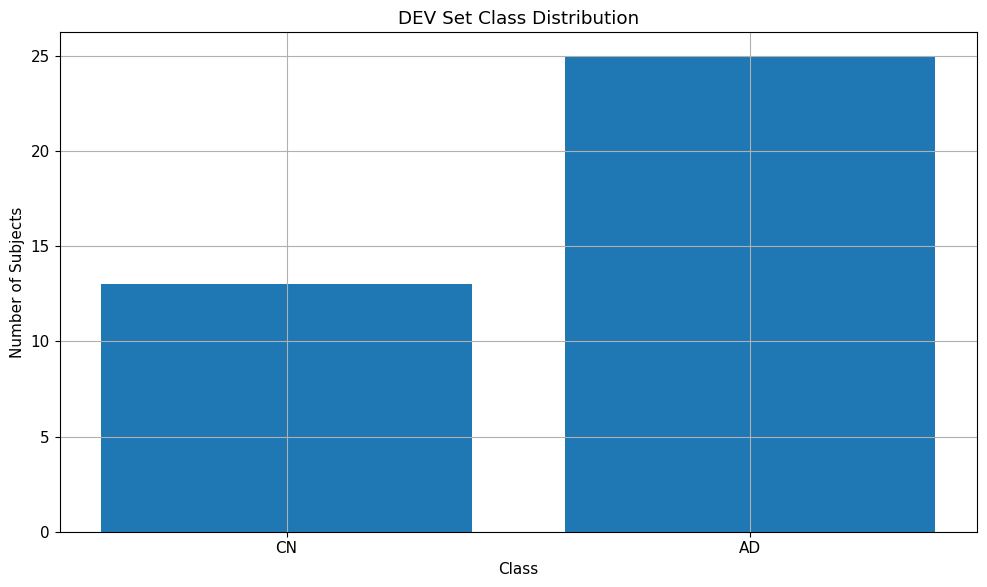

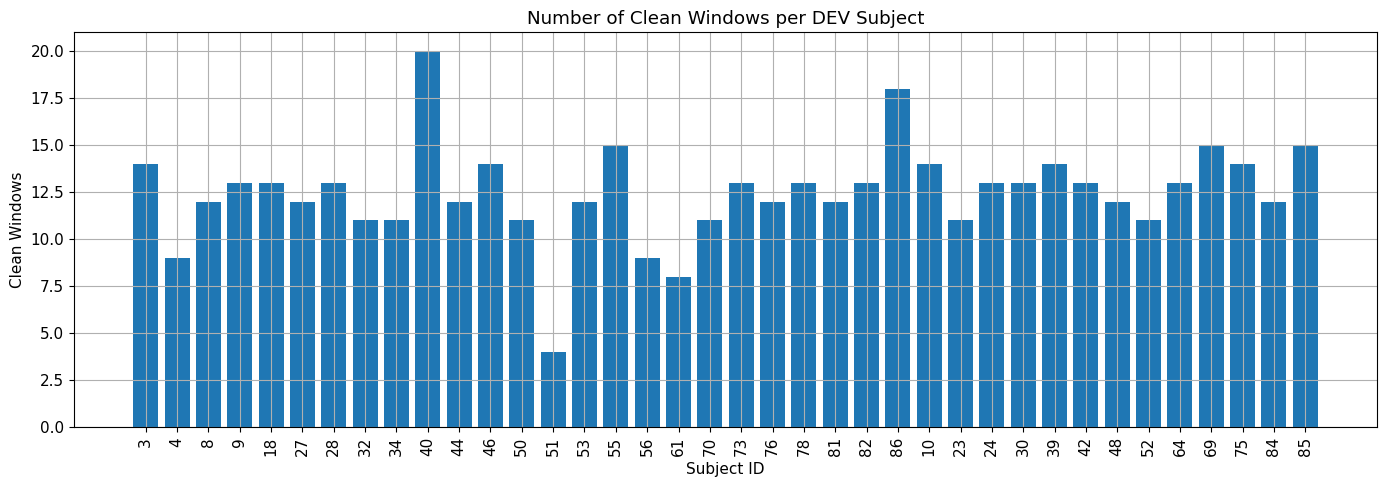

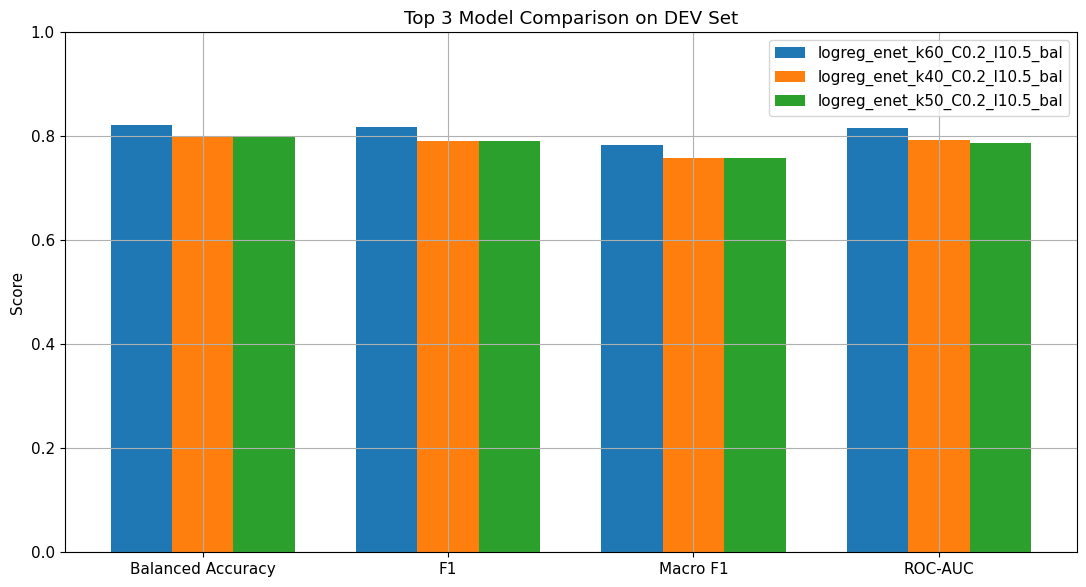

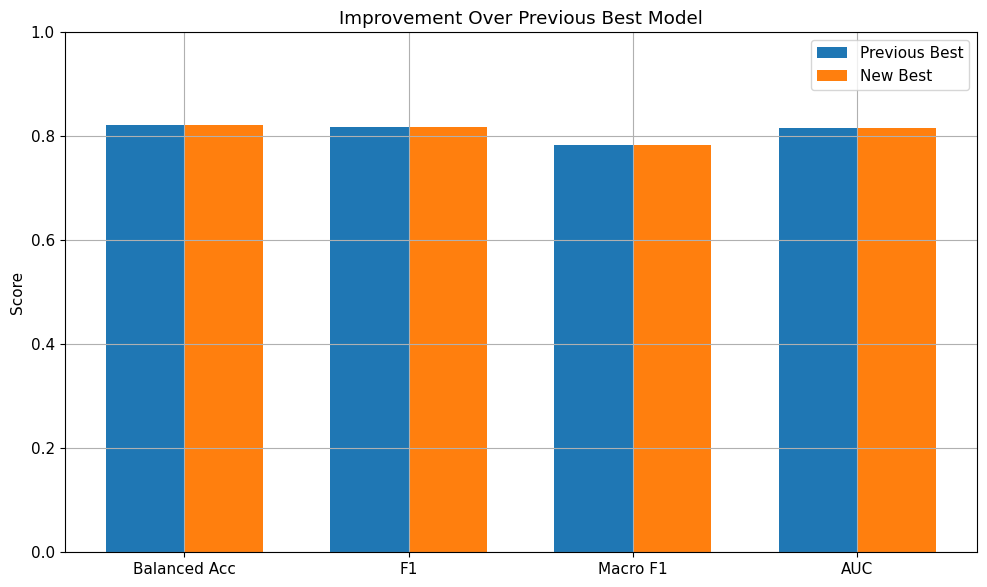

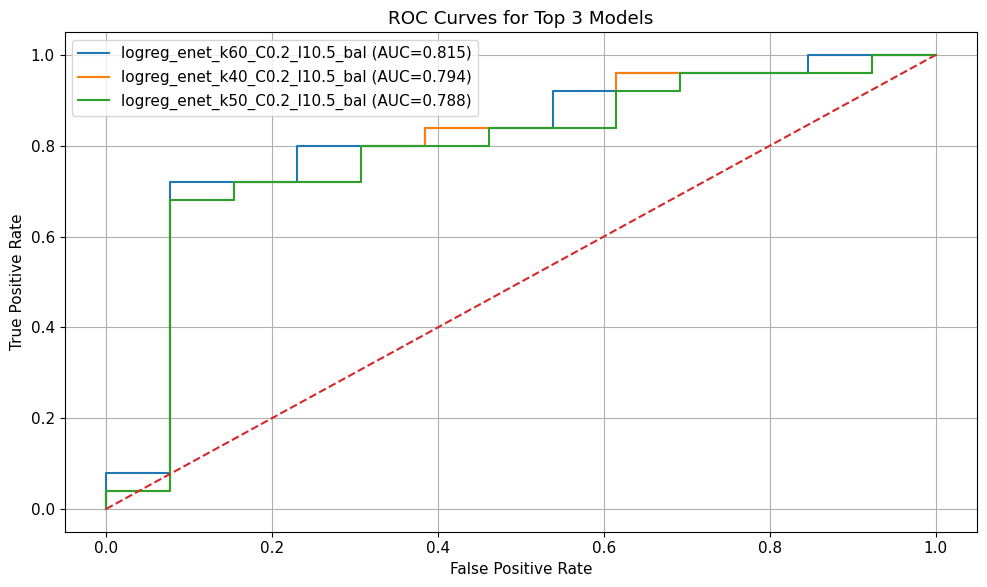

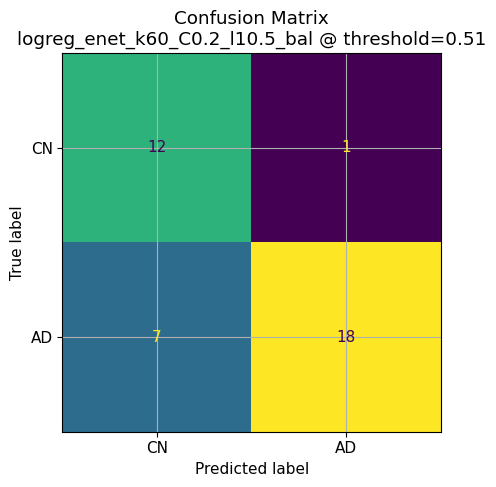

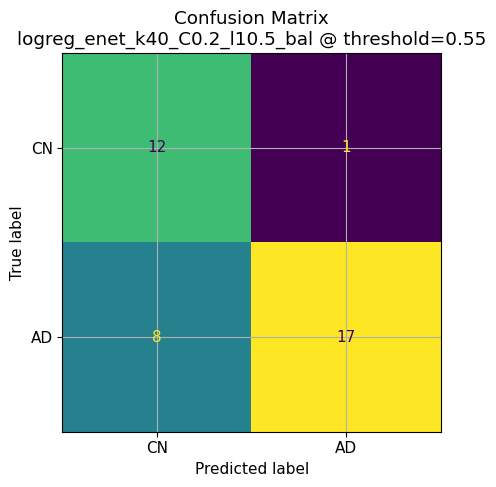

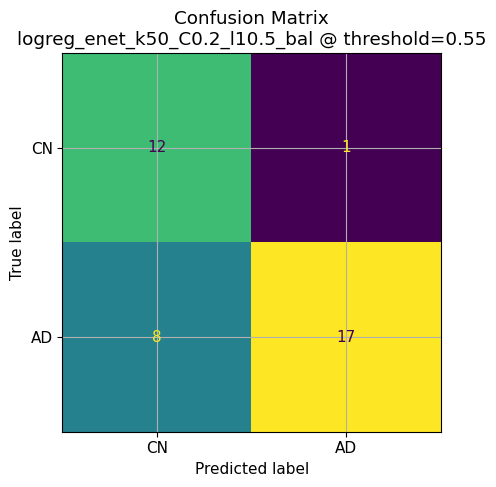

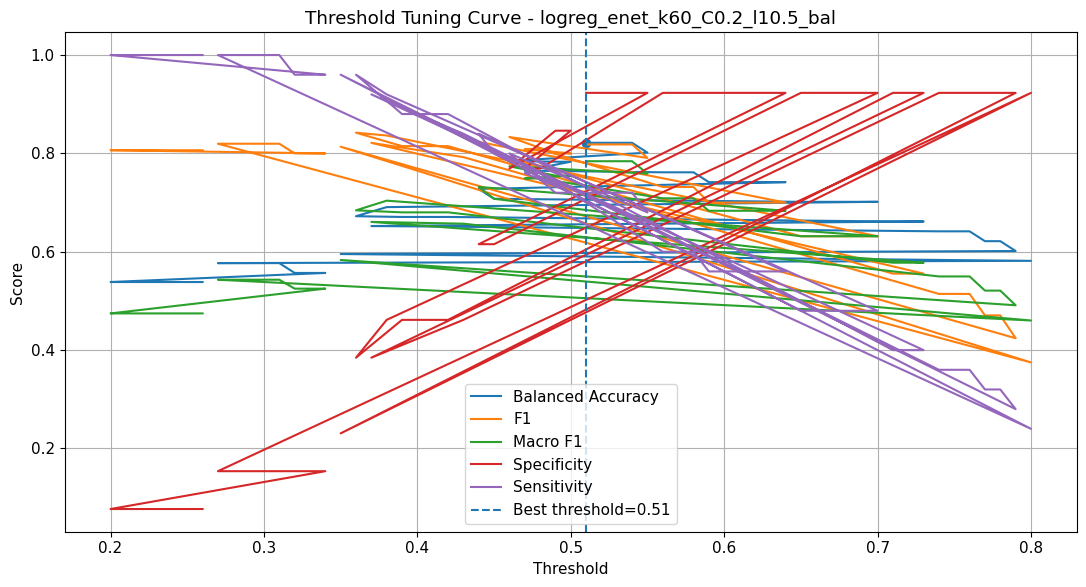

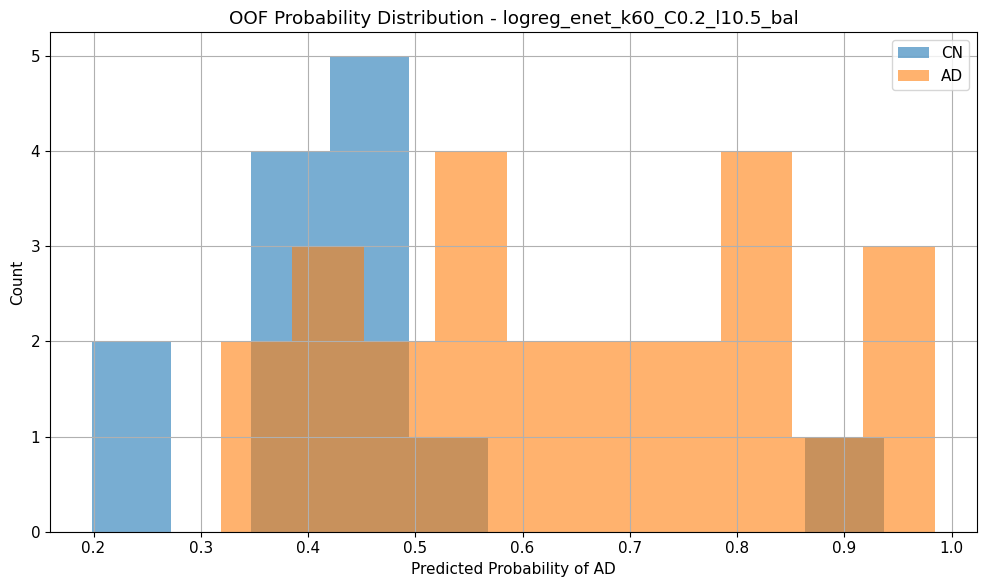

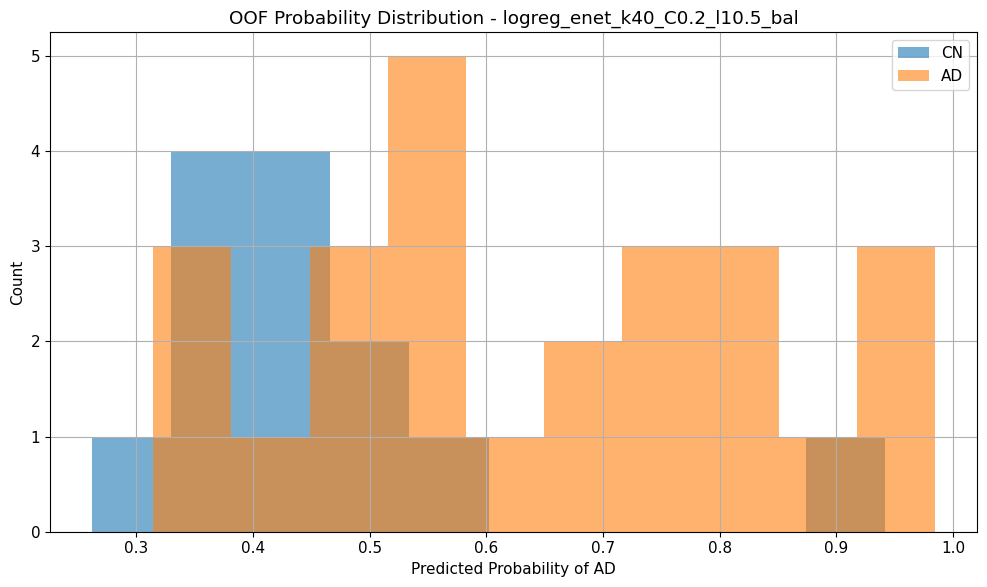

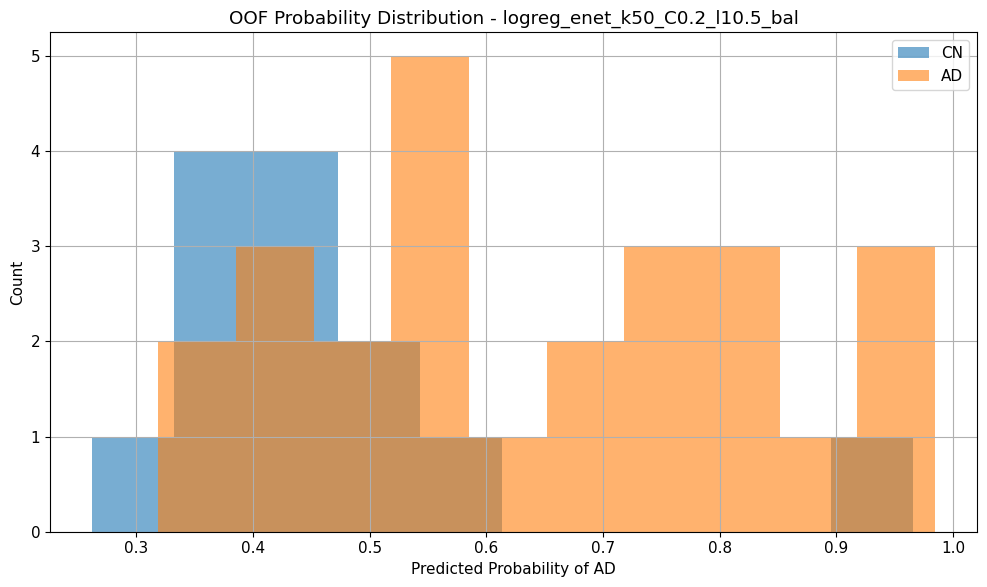

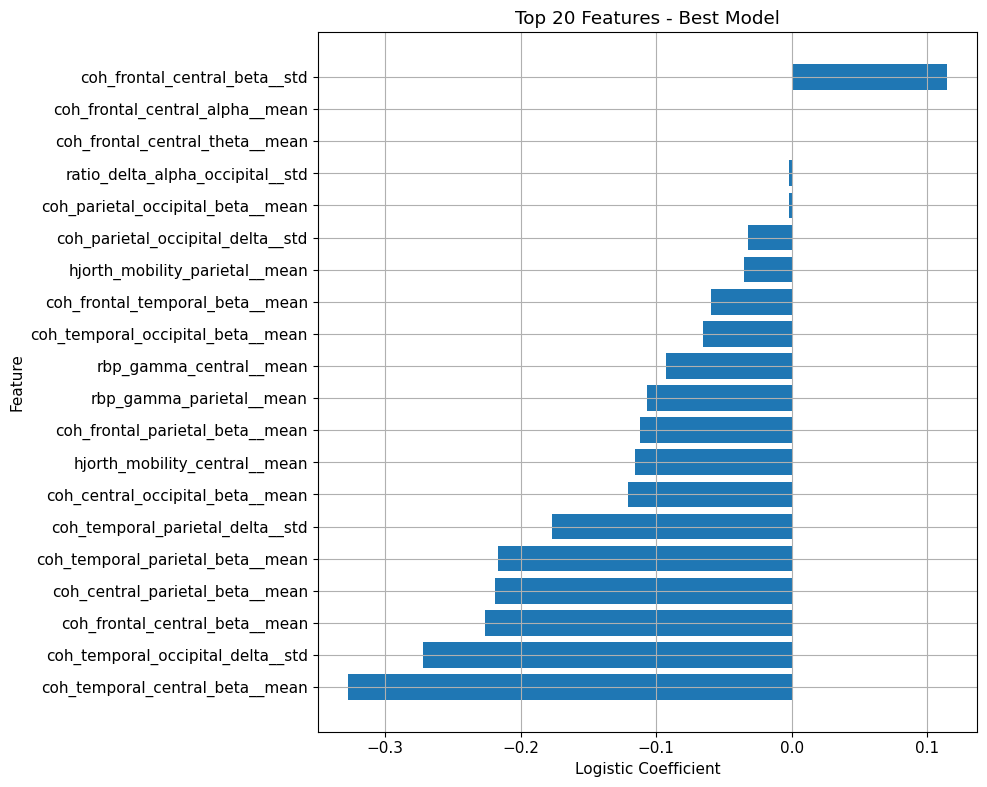

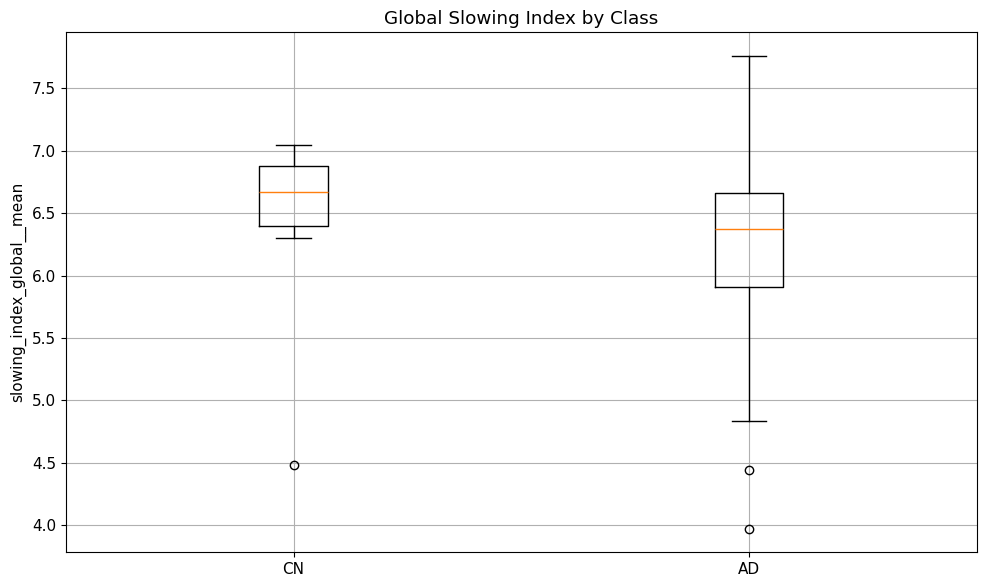

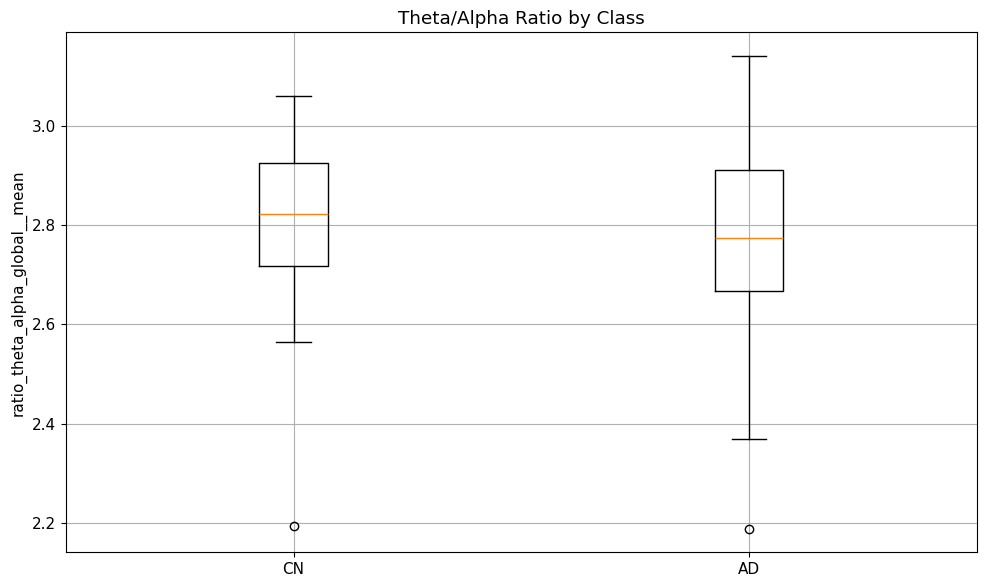

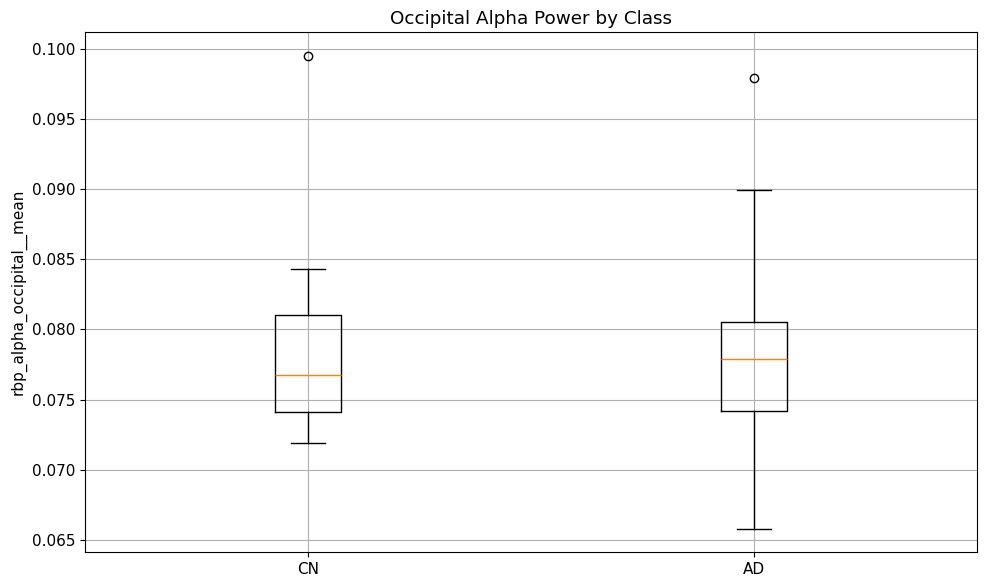

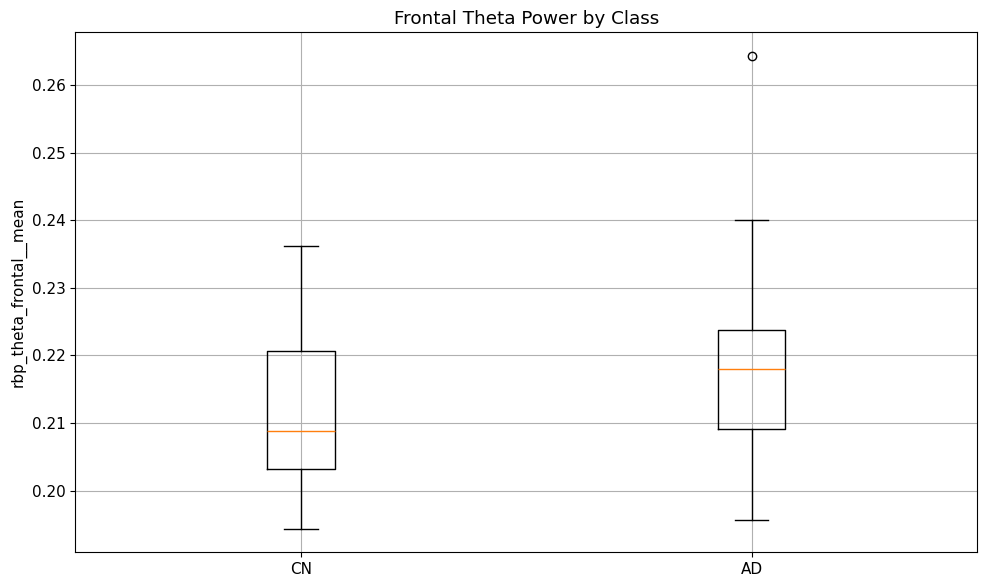

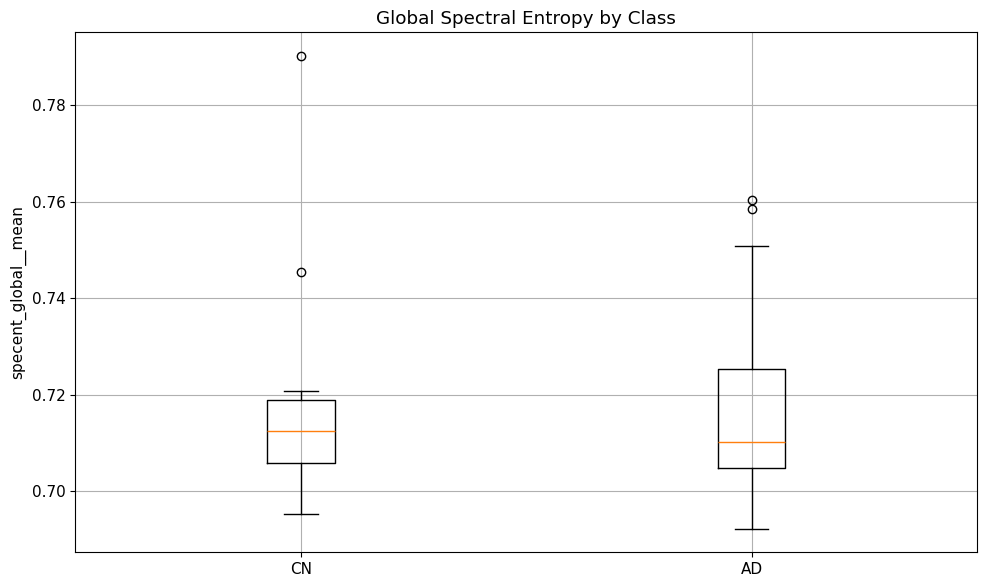

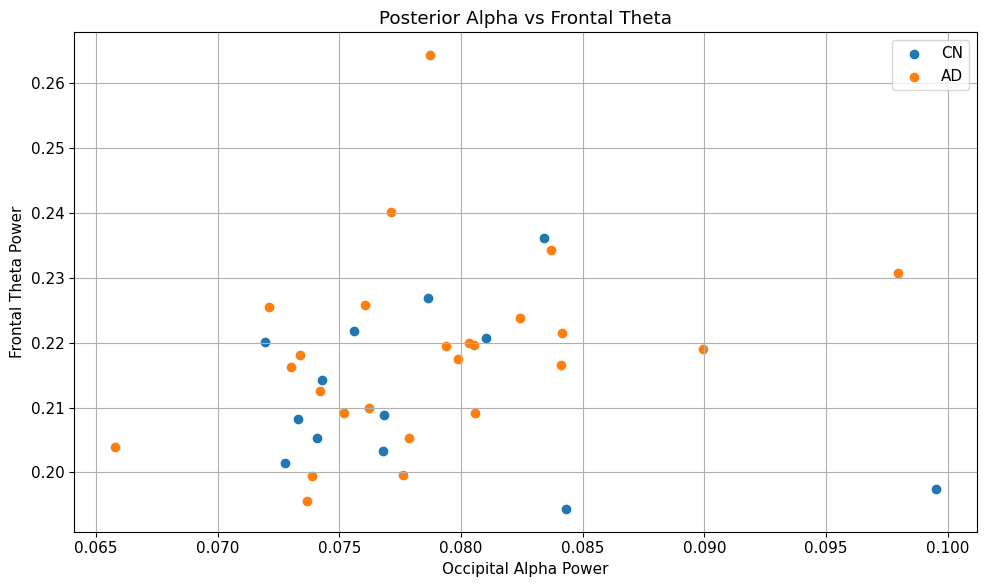

Saved top feature table.

================ PRESENTATION SUMMARY ================

Top 3 models:
                         model  threshold_tuned  bacc_tuned  f1_tuned  f1_macro_tuned  auc_tuned
logreg_enet_k60_C0.2_l10.5_bal             0.51    0.821538  0.818182        0.784091   0.815385
logreg_enet_k40_C0.2_l10.5_bal             0.55    0.801538  0.790698        0.758985   0.793846
logreg_enet_k50_C0.2_l10.5_bal             0.55    0.801538  0.790698        0.758985   0.787692

Best model:
logreg_enet_k60_C0.2_l10.5_bal
Threshold: 0.51

Most important features:
                          feature      coef  abs_coef
  coh_temporal_central_beta__mean -0.327502  0.327502
coh_temporal_occipital_delta__std -0.271578  0.271578
   coh_frontal_central_beta__mean -0.226451  0.226451
  coh_central_parietal_beta__mean -0.218856  0.218856
 coh_temporal_parietal_beta__mean -0.216602  0.216602
 coh_temporal_parietal_delta__std -0.176552  0.176552
 coh_central_occipital_beta__mean -0.121032  0.12103

In [3]:

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ------------------------------------------------------------
# 1) Load saved artifacts if needed
# ------------------------------------------------------------
RESULTS_CSV = f"{BASE_DIR}/dev_cv_results_biomarker_rich.csv"
DEV_PREDS_CSV = f"{BASE_DIR}/dev_oof_predictions_biomarker_rich.csv"
BEST_MODEL_PKL = f"{BASE_DIR}/best_dev_model_biomarker_rich.pkl"

if "results_df" not in globals():
    results_df = pd.read_csv(RESULTS_CSV)

if "oof_df" not in globals() and os.path.exists(DEV_PREDS_CSV):
    oof_df = pd.read_csv(DEV_PREDS_CSV)

if "best_model" not in globals() or "best_threshold" not in globals():
    with open(BEST_MODEL_PKL, "rb") as f:
        payload = pickle.load(f)
    best_model = payload["model"]
    best_threshold = payload["threshold"]
    best_model_name = payload["model_name"]
else:
    best_model_name = best_row["model"] if "best_row" in globals() else "best_model"

print("Best model:", best_model_name)
print("Best threshold:", best_threshold)

# ------------------------------------------------------------
# 2) Top 3 models
# ------------------------------------------------------------
top3 = results_df.sort_values(
    ["bacc_tuned", "f1_macro_tuned", "f1_tuned", "auc_tuned"],
    ascending=False
).head(3).copy()

top3_names = top3["model"].tolist()
print("Top 3 models:", top3_names)

# ------------------------------------------------------------
# 3) General plotting style
# ------------------------------------------------------------
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

OUTPUT_FIG_DIR = f"{BASE_DIR}/presentation_figures"
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

# ------------------------------------------------------------
# 4) Class distribution in DEV set
# ------------------------------------------------------------
def plot_class_distribution():
    unique, counts = np.unique(y_dev, return_counts=True)
    labels = ["CN" if u == 0 else "AD" for u in unique]

    plt.figure()
    plt.bar(labels, counts)
    plt.title("DEV Set Class Distribution")
    plt.ylabel("Number of Subjects")
    plt.xlabel("Class")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/01_class_distribution.png", dpi=200)
    plt.show()

plot_class_distribution()

# ------------------------------------------------------------
# 5) Windows per subject
# ------------------------------------------------------------
def plot_windows_per_subject():
    df = meta_dev.copy()
    df["group_name"] = np.where(df["label"] == 1, "AD", "CN")
    df = df.sort_values(["group_name", "subject_id"])

    plt.figure(figsize=(14, 5))
    x = np.arange(len(df))
    plt.bar(x, df["n_windows"].values)
    plt.xticks(x, df["subject_id"].astype(str), rotation=90)
    plt.title("Number of Clean Windows per DEV Subject")
    plt.xlabel("Subject ID")
    plt.ylabel("Clean Windows")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/02_windows_per_subject.png", dpi=200)
    plt.show()

plot_windows_per_subject()

# ------------------------------------------------------------
# 6) Top-3 model comparison bar chart
# ------------------------------------------------------------
def plot_top3_metric_comparison(top3_df):
    metrics = ["bacc_tuned", "f1_tuned", "f1_macro_tuned", "auc_tuned"]
    metric_labels = ["Balanced Accuracy", "F1", "Macro F1", "ROC-AUC"]

    x = np.arange(len(metrics))
    width = 0.25

    plt.figure(figsize=(11, 6))
    for i, (_, row) in enumerate(top3_df.iterrows()):
        vals = [row[m] for m in metrics]
        plt.bar(x + i * width - width, vals, width=width, label=row["model"])

    plt.xticks(x, metric_labels)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Top 3 Model Comparison on DEV Set")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/03_top3_metric_comparison.png", dpi=200)
    plt.show()

plot_top3_metric_comparison(top3)

# ------------------------------------------------------------
# 7) Improvement vs previous best
# ------------------------------------------------------------
def plot_improvement_vs_previous(best_row):
    labels = ["Balanced Acc", "F1", "Macro F1", "AUC"]
    prev = [
        PREV_BASELINE["bacc_tuned"],
        PREV_BASELINE["f1_tuned"],
        PREV_BASELINE["f1_macro_tuned"],
        PREV_BASELINE["auc_tuned"],
    ]
    new = [
        best_row["bacc_tuned"],
        best_row["f1_tuned"],
        best_row["f1_macro_tuned"],
        best_row["auc_tuned"],
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure()
    plt.bar(x - width/2, prev, width=width, label="Previous Best")
    plt.bar(x + width/2, new, width=width, label="New Best")
    plt.xticks(x, labels)
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.title("Improvement Over Previous Best Model")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/04_improvement_vs_previous.png", dpi=200)
    plt.show()

best_row_local = results_df.sort_values(
    ["bacc_tuned", "f1_macro_tuned", "f1_tuned", "auc_tuned"],
    ascending=False
).iloc[0]
plot_improvement_vs_previous(best_row_local)

# ------------------------------------------------------------
# 8) ROC curves for top 3 models
# ------------------------------------------------------------
def plot_top3_roc_curves(oof_df, y_true, top3_names):
    plt.figure()
    for model_name in top3_names:
        col = f"prob_{model_name}"
        if col not in oof_df.columns:
            continue
        probs = oof_df[col].values
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves for Top 3 Models")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/05_top3_roc_curves.png", dpi=200)
    plt.show()

plot_top3_roc_curves(oof_df, y_dev, top3_names)

# ------------------------------------------------------------
# 9) Confusion matrices for top 3 models at tuned thresholds
# ------------------------------------------------------------
def plot_confusion_matrix_for_model(oof_df, y_true, model_name, threshold, filename):
    col = f"prob_{model_name}"
    if col not in oof_df.columns:
        print(f"Missing OOF probabilities for {model_name}")
        return

    probs = oof_df[col].values
    preds = (probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, preds)

    fig, ax = plt.subplots(figsize=(5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["CN", "AD"])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix\n{model_name} @ threshold={threshold:.2f}")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/{filename}", dpi=200)
    plt.show()

for i, (_, row) in enumerate(top3.iterrows(), start=1):
    plot_confusion_matrix_for_model(
        oof_df=oof_df,
        y_true=y_dev,
        model_name=row["model"],
        threshold=row["threshold_tuned"],
        filename=f"06_confusion_matrix_top{i}.png"
    )

# ------------------------------------------------------------
# 10) Threshold tuning curve for best model
# ------------------------------------------------------------
def plot_threshold_curve(thresholds_csv, best_model_name):
    thresh_df = pd.read_csv(thresholds_csv)
    sub = thresh_df[thresh_df["model"] == best_model_name].copy()

    plt.figure(figsize=(11, 6))
    plt.plot(sub["threshold"], sub["balanced_accuracy"], label="Balanced Accuracy")
    plt.plot(sub["threshold"], sub["f1"], label="F1")
    plt.plot(sub["threshold"], sub["f1_macro"], label="Macro F1")
    plt.plot(sub["threshold"], sub["specificity"], label="Specificity")
    plt.plot(sub["threshold"], sub["sensitivity"], label="Sensitivity")

    best_idx = sub["balanced_accuracy"].idxmax()
    best_thr = sub.loc[best_idx, "threshold"]
    best_bacc = sub.loc[best_idx, "balanced_accuracy"]

    plt.axvline(best_thr, linestyle="--", label=f"Best threshold={best_thr:.2f}")
    plt.scatter([best_thr], [best_bacc])

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"Threshold Tuning Curve - {best_model_name}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/07_threshold_curve_best_model.png", dpi=200)
    plt.show()

plot_threshold_curve(THRESHOLDS_CSV, best_model_name)

# ------------------------------------------------------------
# 11) Predicted probability distributions for top 3 models
# ------------------------------------------------------------
def plot_probability_histograms(oof_df, y_true, top3_names):
    for model_name in top3_names:
        col = f"prob_{model_name}"
        if col not in oof_df.columns:
            continue

        probs = oof_df[col].values
        probs_cn = probs[y_true == 0]
        probs_ad = probs[y_true == 1]

        plt.figure()
        plt.hist(probs_cn, bins=10, alpha=0.6, label="CN")
        plt.hist(probs_ad, bins=10, alpha=0.6, label="AD")
        plt.xlabel("Predicted Probability of AD")
        plt.ylabel("Count")
        plt.title(f"OOF Probability Distribution - {model_name}")
        plt.legend()
        plt.tight_layout()
        safe_name = model_name.replace("/", "_")
        plt.savefig(f"{OUTPUT_FIG_DIR}/08_prob_hist_{safe_name}.png", dpi=200)
        plt.show()

plot_probability_histograms(oof_df, y_dev, top3_names)

# ------------------------------------------------------------
# 12) Feature importance from best logistic model
# ------------------------------------------------------------
def plot_best_model_feature_importance(best_model, feature_names, top_n=20):
    pipe = best_model
    selector = pipe.named_steps["select"]
    clf = pipe.named_steps["clf"]

    selected_mask = selector.get_support()
    selected_features = np.array(feature_names)[selected_mask]
    coefs = clf.coef_.ravel()

    imp_df = pd.DataFrame({
        "feature": selected_features,
        "coef": coefs,
        "abs_coef": np.abs(coefs)
    }).sort_values("abs_coef", ascending=False)

    top_df = imp_df.head(top_n).copy()
    top_df = top_df.sort_values("coef")

    plt.figure(figsize=(10, 8))
    plt.barh(top_df["feature"], top_df["coef"])
    plt.xlabel("Logistic Coefficient")
    plt.ylabel("Feature")
    plt.title(f"Top {top_n} Features - Best Model")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/09_top_feature_importance.png", dpi=220)
    plt.show()

    return imp_df

feature_importance_df = plot_best_model_feature_importance(best_model, feature_names, top_n=20)

# ------------------------------------------------------------
# 13) Build a subject-level feature dataframe for biomarker plots
# ------------------------------------------------------------
X_dev_df = pd.DataFrame(X_dev, columns=feature_names)
subject_plot_df = meta_dev.copy().reset_index(drop=True)
subject_plot_df["group_name"] = np.where(subject_plot_df["label"] == 1, "AD", "CN")

for col in [
    "slowing_index_global__mean",
    "ratio_theta_alpha_global__mean",
    "ratio_delta_alpha_global__mean",
    "rbp_alpha_occipital__mean",
    "rbp_theta_frontal__mean",
    "specent_global__mean",
    "hjorth_mobility_global__mean",
    "hjorth_complexity_global__mean",
]:
    if col in X_dev_df.columns:
        subject_plot_df[col] = X_dev_df[col].values

# ------------------------------------------------------------
# 14) Biomarker boxplots
# ------------------------------------------------------------
def boxplot_by_class(df, col, title, filename):
    if col not in df.columns:
        print(f"Missing column: {col}")
        return

    plt.figure()
    data_cn = df.loc[df["label"] == 0, col].dropna().values
    data_ad = df.loc[df["label"] == 1, col].dropna().values

    plt.boxplot([data_cn, data_ad], labels=["CN", "AD"])
    plt.ylabel(col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/{filename}", dpi=200)
    plt.show()

boxplot_by_class(
    subject_plot_df,
    "slowing_index_global__mean",
    "Global Slowing Index by Class",
    "10_box_slowing_index.png"
)

boxplot_by_class(
    subject_plot_df,
    "ratio_theta_alpha_global__mean",
    "Theta/Alpha Ratio by Class",
    "11_box_theta_alpha.png"
)

boxplot_by_class(
    subject_plot_df,
    "rbp_alpha_occipital__mean",
    "Occipital Alpha Power by Class",
    "12_box_occipital_alpha.png"
)

boxplot_by_class(
    subject_plot_df,
    "rbp_theta_frontal__mean",
    "Frontal Theta Power by Class",
    "13_box_frontal_theta.png"
)

boxplot_by_class(
    subject_plot_df,
    "specent_global__mean",
    "Global Spectral Entropy by Class",
    "14_box_spectral_entropy.png"
)

# ------------------------------------------------------------
# 15) Scatter: posterior alpha vs frontal theta
# ------------------------------------------------------------
def scatter_two_biomarkers(df):
    xcol = "rbp_alpha_occipital__mean"
    ycol = "rbp_theta_frontal__mean"

    if xcol not in df.columns or ycol not in df.columns:
        print("Missing scatter biomarker columns.")
        return

    plt.figure()
    for label, name in [(0, "CN"), (1, "AD")]:
        sub = df[df["label"] == label]
        plt.scatter(sub[xcol], sub[ycol], label=name)

    plt.xlabel("Occipital Alpha Power")
    plt.ylabel("Frontal Theta Power")
    plt.title("Posterior Alpha vs Frontal Theta")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_FIG_DIR}/15_scatter_alpha_theta.png", dpi=200)
    plt.show()

scatter_two_biomarkers(subject_plot_df)

# ------------------------------------------------------------
# 16) Top features table for presentation
# ------------------------------------------------------------
top_feature_table = feature_importance_df.head(15).copy()
top_feature_table.to_csv(f"{OUTPUT_FIG_DIR}/top_feature_table.csv", index=False)
print("Saved top feature table.")

# ------------------------------------------------------------
# 17) Summary slide-ready text output
# ------------------------------------------------------------
print("\n================ PRESENTATION SUMMARY ================\n")
print("Top 3 models:")
print(top3[[
    "model", "threshold_tuned", "bacc_tuned", "f1_tuned", "f1_macro_tuned", "auc_tuned"
]].to_string(index=False))

print("\nBest model:")
print(best_model_name)
print(f"Threshold: {best_threshold:.2f}")

print("\nMost important features:")
print(feature_importance_df.head(10)[["feature", "coef", "abs_coef"]].to_string(index=False))

print(f"\nAll figures saved to: {OUTPUT_FIG_DIR}")

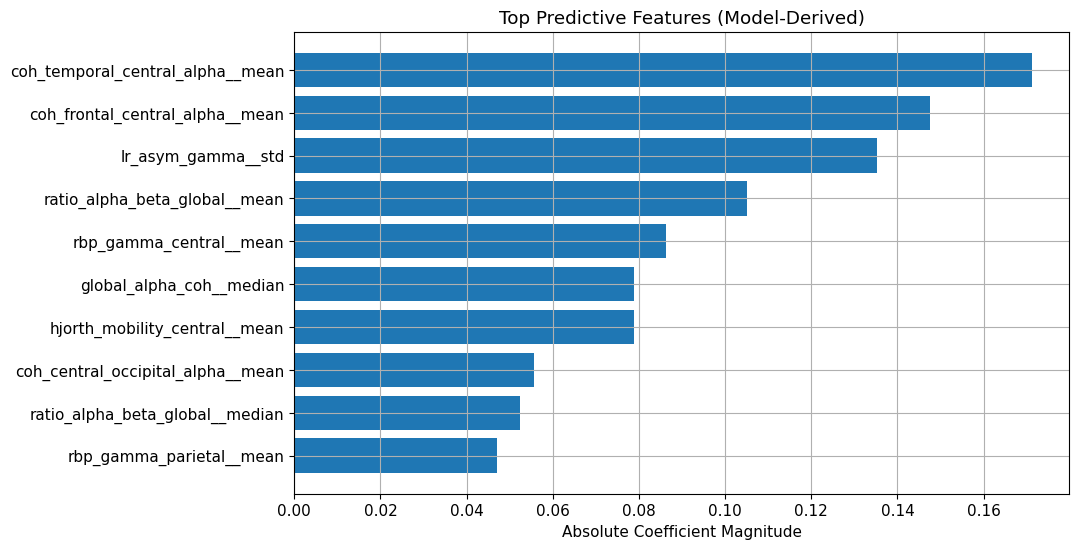

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load saved model
with open(BEST_MODEL_PKL, "rb") as f:
    payload = pickle.load(f)

model = payload["model"]
feature_names = payload["feature_names"]

# Extract pipeline steps
selector = model.named_steps["select"]
clf = model.named_steps["clf"]

# Get selected features
selected_idx = selector.get_support(indices=True)
selected_features = [feature_names[i] for i in selected_idx]

# Get coefficients
coefs = clf.coef_[0]

# Build dataframe
df_imp = pd.DataFrame({
    "feature": selected_features,
    "importance": np.abs(coefs)
})

# Sort top features
df_imp = df_imp.sort_values("importance", ascending=False).head(10)

# Plot
plt.figure()
plt.barh(df_imp["feature"], df_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Top Predictive Features (Model-Derived)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.show()

In [5]:
import pandas as pd

# Path to your saved file
path = "/content/drive/MyDrive/eeg_hackathon/test_predictions_final.csv"

df = pd.read_csv(path)

df.head(20)

,subject_id,n_windows,file_path,prob_ad,pred,pred_label
0,5,12,/content/drive/MyDrive/eeg_hackathon/testing/5...,0.312939,0,C
1,6,12,/content/drive/MyDrive/eeg_hackathon/testing/6...,0.225257,0,C
2,7,9,/content/drive/MyDrive/eeg_hackathon/testing/7...,0.619999,1,A
3,12,14,/content/drive/MyDrive/eeg_hackathon/testing/1...,0.304440,0,C
4,17,12,/content/drive/MyDrive/eeg_hackathon/testing/1...,0.388376,0,C
5,19,12,/content/drive/MyDrive/eeg_hackathon/testing/1...,0.410834,0,C
6,20,14,/content/drive/MyDrive/eeg_hackathon/testing/2...,0.273445,0,C
7,21,13,/content/drive/MyDrive/eeg_hackathon/testing/2...,0.951183,1,A
8,22,11,/content/drive/MyDrive/eeg_hackathon/testing/2...,0.245228,0,C
9,25,12,/content/drive/MyDrive/eeg_hackathon/testing/2...,0.728195,1,A
